In [2]:
import pandas as pd
import numpy as np

import tubesml as tml

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from os.path import join, isfile
from os import path, scandir, listdir

from source.aggregated_stats import process_details, full_stats

pd.set_option("max_columns", 300)

In [3]:
def list_all_files(location='../input/', pattern=None, recursive=True):
    """
    This function returns a list of files at a given location (including subfolders)
    
    - location: path to the directory to be searched
    - pattern: part of the file name to be searched (ex. pattern='.csv' would return all the csv files)
    - recursive: boolean, if True the function calls itself for every subdirectory it finds
    """
    subdirectories= [f.path for f in scandir(location) if f.is_dir()]
    files = [join(location, f) for f in listdir(location) if isfile(join(location, f))]
    if recursive:
        for directory in subdirectories:
            files.extend(list_all_files(directory))
    if pattern:
        files = [f for f in files if pattern in f]
    return files

In [4]:
men_comp = list_all_files('data/raw_men/')

In [5]:
men_comp

['data/raw_men/M2021_Stage1/MConferenceTourneyGames.csv',
 'data/raw_men/M2021_Stage1/MNCAATourneySeeds.csv',
 'data/raw_men/M2021_Stage1/Conferences.csv',
 'data/raw_men/M2021_Stage1/MNCAATourneyDetailedResults.csv',
 'data/raw_men/M2021_Stage1/Cities.csv',
 'data/raw_men/M2021_Stage1/MSeasons.csv',
 'data/raw_men/M2021_Stage1/MNCAATourneySlots.csv',
 'data/raw_men/M2021_Stage1/MTeamConferences.csv',
 'data/raw_men/M2021_Stage1/MSecondaryTourneyTeams.csv',
 'data/raw_men/M2021_Stage1/MGameCities.csv',
 'data/raw_men/M2021_Stage1/MSampleSubmissionStage1.csv',
 'data/raw_men/M2021_Stage1/MTeamCoaches.csv',
 'data/raw_men/M2021_Stage1/MTeams.csv',
 'data/raw_men/M2021_Stage1/MNCAATourneyCompactResults.csv',
 'data/raw_men/M2021_Stage1/MSecondaryTourneyCompactResults.csv',
 'data/raw_men/M2021_Stage1/MRegularSeasonCompactResults.csv',
 'data/raw_men/M2021_Stage1/MMasseyOrdinals.csv',
 'data/raw_men/M2021_Stage1/MNCAATourneySeedRoundSlots.csv',
 'data/raw_men/M2021_Stage1/MTeamSpellings.cs

# submission file

In [7]:
[col for col in men_comp if 'Submission' in col]

['data/raw_men/M2021_Stage1/MSampleSubmissionStage1.csv',
 'data/raw_men/MDataFiles_Stage2/MSampleSubmissionStage2.csv']

In [8]:
df = pd.read_csv('data/raw_men/MDataFiles_Stage2/MSampleSubmissionStage2.csv')
df[['year', 'Team_1', 'Team_2']] = pd.DataFrame(df['ID'].str.split('_').values.tolist(), index=df.index)
df['year'] = pd.to_numeric(df.year)
df.head()

,ID,Pred,year,Team_1,Team_2
0,2021_1101_1104,0.5,2021,1101,1104
1,2021_1101_1111,0.5,2021,1101,1111
2,2021_1101_1116,0.5,2021,1101,1116
3,2021_1101_1124,0.5,2021,1101,1124
4,2021_1101_1140,0.5,2021,1101,1140


In [9]:
df.year.value_counts(dropna=False)

2021    2278
Name: year, dtype: int64

# Teams.csv

In [10]:
[file for file in men_comp if 'Teams.csv' in file]

['data/raw_men/M2021_Stage1/MSecondaryTourneyTeams.csv',
 'data/raw_men/M2021_Stage1/MTeams.csv',
 'data/raw_men/MDataFiles_Stage2/MSecondaryTourneyTeams.csv',
 'data/raw_men/MDataFiles_Stage2/MTeams.csv']

In [11]:
df = pd.read_csv('data/raw_men/MDataFiles_Stage2/MTeams.csv')
print(df.shape)
df.head()

(371, 4)


,TeamID,TeamName,FirstD1Season,LastD1Season
0,1101,Abilene Chr,2014,2021
1,1102,Air Force,1985,2021
2,1103,Akron,1985,2021
3,1104,Alabama,1985,2021
4,1105,Alabama A&M,2000,2021


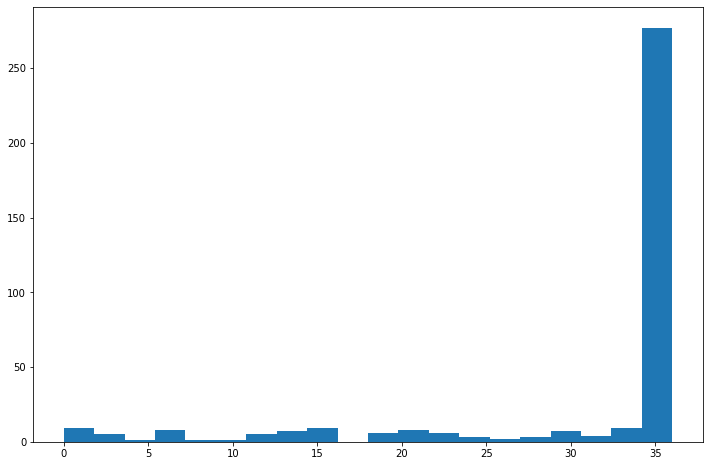

In [12]:
df['years_in_d1'] = df['LastD1Season'] - df['FirstD1Season']

df['years_in_d1'].hist(bins=20, figsize=(12,8))
plt.grid(False)

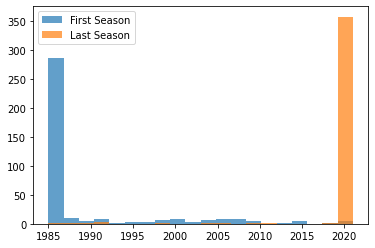

In [13]:
df.FirstD1Season.hist(bins=20, alpha=0.7, label='First Season')
df.LastD1Season.hist(bins=20, alpha=0.7, label='Last Season')
plt.grid(False)
plt.legend()

In [14]:
yr_count = pd.DataFrame({'year': np.arange(1985, 2022)})

for year in yr_count.year:
    df['is_in'] = 0
    df.loc[(df.FirstD1Season <= year) & (df.LastD1Season >= year), 'is_in'] = 1
    tot_teams = df.is_in.sum()
    yr_count.loc[yr_count.year == year, 'n_teams'] = tot_teams

<AxesSubplot:xlabel='year'>

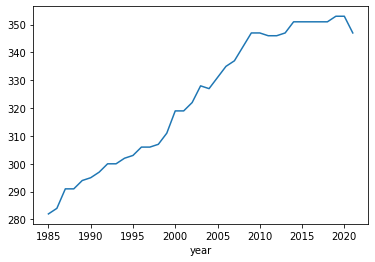

In [15]:
yr_count = yr_count.set_index('year')
yr_count.n_teams.plot()

In [16]:
df = pd.read_csv('data/raw_men/MDataFiles_Stage2/MSecondaryTourneyTeams.csv')
print(df.shape)
df.head()

(1642, 3)


,Season,SecondaryTourney,TeamID
0,1985,NIT,1108
1,1985,NIT,1133
2,1985,NIT,1139
3,1985,NIT,1145
4,1985,NIT,1151


In [17]:
df.SecondaryTourney.value_counts()

NIT    1160
CIT     282
CBI     192
V16       8
Name: SecondaryTourney, dtype: int64

# Seasons.csv

In [18]:
[file for file in men_comp if 'Seasons.csv' in file]

['data/raw_men/M2021_Stage1/MSeasons.csv',
 'data/raw_men/MDataFiles_Stage2/MSeasons.csv']

In [19]:
df = pd.read_csv('data/raw_men/MDataFiles_Stage2/MSeasons.csv')
print(df.shape)
df.head()

(37, 6)


,Season,DayZero,RegionW,RegionX,RegionY,RegionZ
0,1985,10/29/1984,East,West,Midwest,Southeast
1,1986,10/28/1985,East,Midwest,Southeast,West
2,1987,10/27/1986,East,Southeast,Midwest,West
3,1988,11/2/1987,East,Midwest,Southeast,West
4,1989,10/31/1988,East,West,Midwest,Southeast


In [20]:
df.RegionW.value_counts()

East           33
Atlanta         2
Albuquerque     1
NA1             1
Name: RegionW, dtype: int64

In [21]:
df.RegionX.value_counts()

Midwest      11
West         10
South         8
Southeast     4
NA2           1
Chicago       1
Phoenix       1
Oakland       1
Name: RegionX, dtype: int64

In [22]:
df.RegionY.value_counts()

Midwest           21
South              6
Southeast          6
NA3                1
EastRutherford     1
Minneapolis        1
Austin             1
Name: RegionY, dtype: int64

In [23]:
df.RegionZ.value_counts()

West            23
South            5
Southeast        4
WashingtonDC     1
Southwest        1
StLouis          1
Syracuse         1
NA4              1
Name: RegionZ, dtype: int64

# Regular season compact results

In [24]:
[file for file in men_comp if 'RegularSeasonCompact' in file]

['data/raw_men/M2021_Stage1/MRegularSeasonCompactResults.csv',
 'data/raw_men/MDataFiles_Stage2/MRegularSeasonCompactResults.csv']

In [25]:
df = pd.read_csv('data/raw_men/MDataFiles_Stage2/MRegularSeasonCompactResults.csv')
print(df.shape)
df.head()

(170738, 8)


,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,1985,20,1228,81,1328,64,N,0
1,1985,25,1106,77,1354,70,H,0
2,1985,25,1112,63,1223,56,H,0
3,1985,25,1165,70,1432,54,H,0
4,1985,25,1192,86,1447,74,H,0


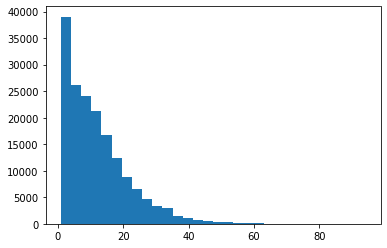

In [26]:
df['point_diff'] = df.WScore - df.LScore
df.point_diff.hist(bins=30)
plt.grid(False)

In [27]:
df.describe()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,NumOT,point_diff
count,170738.000000,170738.000000,170738.000000,170738.000000,170738.000000,170738.000000,170738.000000,170738.000000
mean,2004.153651,74.508258,1287.033273,76.774813,1282.765049,64.679544,0.046176,12.095269
std,10.525748,33.780301,104.587363,11.993386,104.720465,11.299904,0.252621,9.407233
min,1985.000000,0.000000,1101.000000,1.000000,1101.000000,0.000000,0.000000,1.000000
25%,1995.000000,47.000000,1198.000000,69.000000,1191.000000,57.000000,0.000000,5.000000
50%,2005.000000,77.000000,1284.000000,76.000000,1281.000000,64.000000,0.000000,10.000000
75%,2013.000000,103.000000,1380.000000,84.000000,1375.000000,72.000000,0.000000,17.000000
max,2021.000000,132.000000,1471.000000,186.000000,1471.000000,150.000000,6.000000,94.000000


In [28]:
summaries = df[['Season', 
    'WScore', 
    'LScore', 
    'NumOT', 
    'point_diff']].groupby('Season').agg(['min', 'max', 'mean', 'median'])

summaries.columns = ['_'.join(col).strip() for col in summaries.columns.values]
summaries

,WScore_min,WScore_max,WScore_mean,WScore_median,LScore_min,LScore_max,LScore_mean,LScore_median,NumOT_min,NumOT_max,NumOT_mean,NumOT_median,point_diff_min,point_diff_max,point_diff_mean,point_diff_median
Season,,,,,,,,,,,,,,,,
1985,37,142,74.723040,74,27,140,63.860316,64,0,3,0.007760,0,1,60,10.862724,9
1986,35,151,74.813640,74,30,114,63.633888,63,0,2,0.002115,0,1,84,11.179752,9
1987,43,133,77.993870,77,25,111,66.770626,66,0,3,0.008429,0,1,73,11.223244,9
1988,40,152,79.773704,79,31,133,67.697092,67,0,2,0.003793,0,1,68,12.076612,10
1989,43,181,81.728511,81,30,150,69.530840,69,0,2,0.005697,0,1,70,12.197672,10
1990,36,173,80.846477,80,28,141,68.833622,68,0,3,0.006180,0,1,76,12.012855,10
1991,42,186,82.733932,82,27,140,70.057240,69,0,2,0.007519,0,1,68,12.676692,10
1992,41,159,79.992004,79,25,116,67.144657,67,0,3,0.003150,0,1,82,12.847347,11
1993,40,155,79.508790,79,27,112,67.301858,67,0,2,0.004771,0,1,81,12.206931,10


<AxesSubplot:xlabel='Season'>

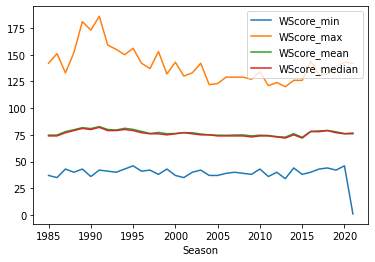

In [29]:
summaries[[col for col in summaries.columns if 'WScore' in col and 'sum' not in col]].plot()

<AxesSubplot:xlabel='Season'>

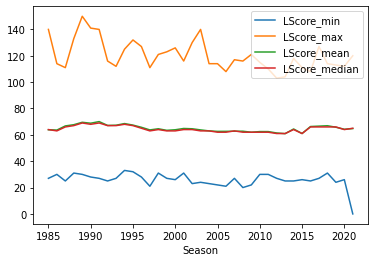

In [30]:
summaries[[col for col in summaries.columns if 'LScore' in col and 'sum' not in col]].plot()

<AxesSubplot:xlabel='Season'>

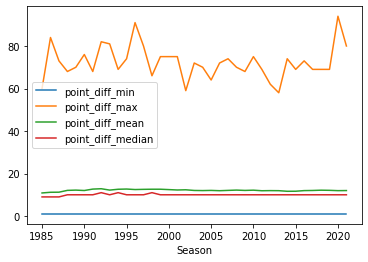

In [31]:
summaries[[col for col in summaries.columns if 'point_diff' in col and 'sum' not in col]].plot()

<AxesSubplot:xlabel='Season'>

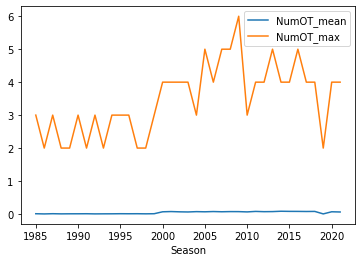

In [32]:
summaries[['NumOT_mean', 'NumOT_max']].plot()

In [33]:
summaries = df[['Season', 'WLoc',
    'WScore', 
    'LScore', 
    'NumOT', 
    'point_diff']].groupby(['Season', 'WLoc']).agg(['min', 'max', 'mean', 'median', 'count'])

summaries.columns = ['_'.join(col).strip() for col in summaries.columns.values]
summaries

WScore_min  WScore_max  WScore_mean  WScore_median  WScore_count  \
Season WLoc                                                                     
1985   A             41         142    72.491023             72          1114   
       H             37         128    75.935383             75          2244   
       N             43         121    74.105541             74           379   
1986   A             35         126    72.163964             72          1110   
       H             42         151    76.169076             76          2283   
...                 ...         ...          ...            ...           ...   
2020   H             46         143    77.065773             77          3208   
       N             47         115    74.446188             74           446   
2021   A             45         123    75.938346             76          1330   
       H             47         142    77.464842             77          2119   
       N              1         112    75.679707             76           409   

             LScore_min  LScore_max  LScore_mean  LScore_median  LScore_count  \
Season WLoc                                                                     
1985   A             35         140    63.952424           63.0          1114   
       H             27         105    63.839127           64.0          2244   
       N             37          96    63.715040           64.0           379   
1986   A             30          97    63.426126           63.0          1110   
       H             31         114    63.786684           63.0          2283   
...                 ...         ...          ...            ...           ...   
2020   H             26         107    63.677681           63.0          3208   
       N             37         112    63.325112           63.0           446   
2021   A             31         120    65.884211           65.0          1330   
       H             30         104    64.086833           64.0          2119   
       N              0          98    64.559902           65.0           409   

             NumOT_min  NumOT_max  NumOT_mean  NumOT_median  NumOT_count  \
Season WLoc                                                                
1985   A             0          3    0.007181             0         1114   
       H             0          1    0.002228             0         2244   
       N             0          3    0.042216             0          379   
1986   A             0          2    0.001802             0         1110   
       H             0          1    0.001752             0         2283   
...                ...        ...         ...           ...          ...   
2020   H             0          4    0.061409             0         3208   
       N             0          3    0.051570             0          446   
2021   A             0          4    0.075940             0         1330   
       H             0          3    0.058046             0         2119   
       N             0          3    0.024450             0          409   

             point_diff_min  point_diff_max  point_diff_mean  \
Season WLoc                                                    
1985   A                  1              43         8.538600   
       H                  1              60        12.096257   
       N                  1              47        10.390501   
1986   A                  1              53         8.737838   
       H                  1              53        12.382392   
...                     ...             ...              ...   
2020   H                  1              94        13.388092   
       N                  1              41        11.121076   
2021   A                  1              47        10.054135   
       H                  1              80        13.378008   
       N                  1              52        11.119804   

             point_diff_median  point_diff_count  
Season WLoc                     

<AxesSubplot:xlabel='Season'>

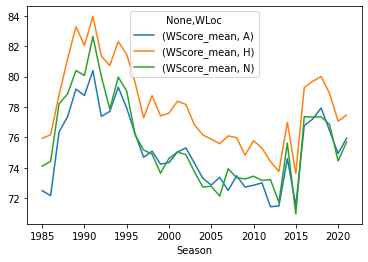

In [34]:
summaries[['WScore_mean']].unstack().plot()

<AxesSubplot:xlabel='Season'>

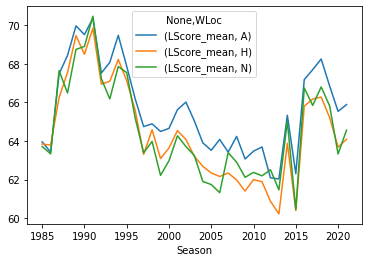

In [35]:
summaries[['LScore_mean']].unstack().plot()

<AxesSubplot:xlabel='Season'>

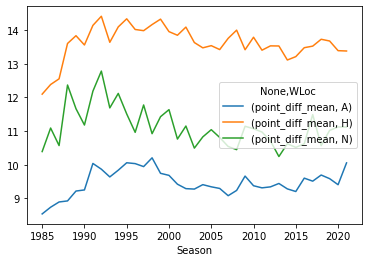

In [36]:
summaries[['point_diff_mean']].unstack().plot()

<AxesSubplot:xlabel='Season'>

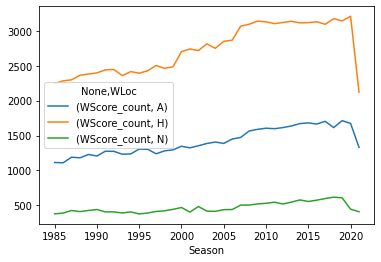

In [37]:
summaries[['WScore_count']].unstack().plot()

# Playoff compact results

In [38]:
[file for file in men_comp if 'NCAATourneyCompact' in file]

['data/raw_men/M2021_Stage1/MNCAATourneyCompactResults.csv',
 'data/raw_men/MDataFiles_Stage2/MNCAATourneyCompactResults.csv']

In [39]:
df = pd.read_csv('data/raw_men/MDataFiles_Stage2/MNCAATourneyCompactResults.csv')
print(df.shape)
df.head()

(2251, 8)


,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,1985,136,1116,63,1234,54,N,0
1,1985,136,1120,59,1345,58,N,0
2,1985,136,1207,68,1250,43,N,0
3,1985,136,1229,58,1425,55,N,0
4,1985,136,1242,49,1325,38,N,0


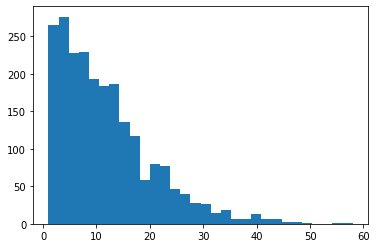

In [40]:
df['point_diff'] = df.WScore - df.LScore
df.point_diff.hist(bins=30)
plt.grid(False)

In [41]:
summaries = df[['Season', 
    'WScore', 
    'LScore', 
    'NumOT', 
    'point_diff']].groupby('Season').agg(['min', 'max', 'mean', 'median'])

summaries.columns = ['_'.join(col).strip() for col in summaries.columns.values]
summaries

,WScore_min,WScore_max,WScore_mean,WScore_median,LScore_min,LScore_max,LScore_mean,LScore_median,NumOT_min,NumOT_max,NumOT_mean,NumOT_median,point_diff_min,point_diff_max,point_diff_mean,point_diff_median
Season,,,,,,,,,,,,,,,,
1985,46,96,68.047619,67.0,38,84,59.333333,58.0,0,1,0.047619,0,1,25,8.714286,7.0
1986,58,101,76.841270,74.0,43,87,66.142857,65.0,0,1,0.079365,0,1,49,10.698413,8.0
1987,57,113,82.603175,83.0,51,97,71.984127,71.0,0,1,0.079365,0,1,34,10.619048,8.0
1988,54,123,83.349206,83.0,47,115,71.285714,72.0,0,1,0.031746,0,1,40,12.063492,10.0
1989,50,124,85.222222,85.0,46,101,73.253968,73.0,0,1,0.047619,0,1,43,11.968254,11.0
1990,49,149,80.761905,78.0,46,115,70.761905,70.0,0,1,0.079365,0,1,35,10.000000,7.0
1991,50,117,80.079365,79.0,48,90,67.809524,68.0,0,1,0.063492,0,1,41,12.269841,10.0
1992,51,106,81.238095,81.0,43,103,68.730159,69.0,0,1,0.063492,0,1,39,12.507937,10.0
1993,54,112,81.761905,81.0,50,84,66.841270,68.0,0,1,0.063492,0,2,45,14.920635,13.0


<AxesSubplot:xlabel='Season'>

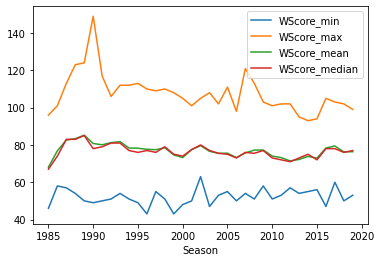

In [42]:
summaries[[col for col in summaries.columns if 'WScore' in col and 'sum' not in col]].plot()

<AxesSubplot:xlabel='Season'>

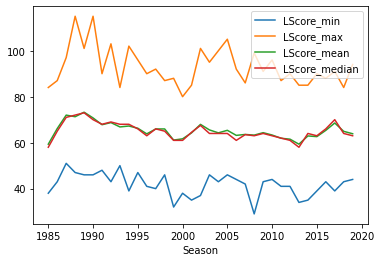

In [43]:
summaries[[col for col in summaries.columns if 'LScore' in col and 'sum' not in col]].plot()

<AxesSubplot:xlabel='Season'>

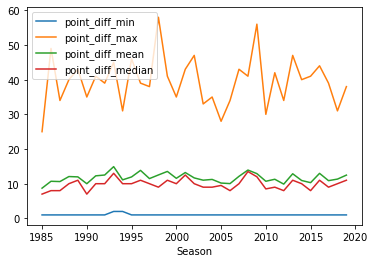

In [44]:
summaries[[col for col in summaries.columns if 'point_diff' in col and 'sum' not in col]].plot()

<AxesSubplot:xlabel='Season'>

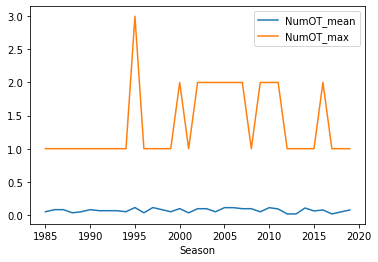

In [45]:
summaries[['NumOT_mean', 'NumOT_max']].plot()

In [46]:
df.WLoc.value_counts()

N    2251
Name: WLoc, dtype: int64

# Detailed results

In [47]:
[col for col in men_comp if 'Detailed' in col]

['data/raw_men/M2021_Stage1/MNCAATourneyDetailedResults.csv',
 'data/raw_men/M2021_Stage1/MRegularSeasonDetailedResults.csv',
 'data/raw_men/MDataFiles_Stage2/MNCAATourneyDetailedResults.csv',
 'data/raw_men/MDataFiles_Stage2/MRegularSeasonDetailedResults.csv']

In [48]:
reg_season = pd.read_csv('data/raw_men/MDataFiles_Stage2/MRegularSeasonDetailedResults.csv')
print(df.shape)
stats = [col for col in reg_season.columns if 'W' in col and 'ID' not in col and 'Loc' not in col]

reg_season = process_details(reg_season)

reg_season.head()

(2251, 9)


,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF,WOT_win,WAway,WFG_perc,WFGM2,WFGA2,WFG2_perc,WFG3_perc,WFT_perc,WTot_Reb,WFGM_no_ast,WFGM_no_ast_perc,Wpossessions,Woff_rating,Wshtg_opportunity,WTO_perposs,WTrue_shooting_perc,LFG_perc,LFGM2,LFGA2,LFG2_perc,LFG3_perc,LFT_perc,LTot_Reb,LFGM_no_ast,LFGM_no_ast_perc,Lpossessions,Loff_rating,Lshtg_opportunity,LTO_perposs,LTrue_shooting_perc,Wdef_rating,Ldef_rating,Wopp_shtg_opportunity,Lopp_shtg_opportunity,Wopp_possessions,Lopp_possessions,Wopp_score,Lopp_score,Wopp_FTA,Wopp_FGA,Lopp_FTA,Lopp_FGA,Wimpact,Limpact,WDR_opportunity,LDR_opportunity,WOR_opportunity,LOR_opportunity,Score_diff,FGM_diff,FGA_diff,FGM3_diff,FGA3_diff,FTM_diff,FTA_diff,OR_diff,DR_diff,Ast_diff,TO_diff,Stl_diff,Blk_diff,PF_diff,FGM2_diff,FGA2_diff,Tot_Reb_diff,FGM_no_ast_diff,DR_opportunity_diff,OR_opportunity_diff,possessions_diff,off_rating_diff,def_rating_diff,shtg_opportunity_diff,TO_perposs_diff,impact_diff,True_shooting_perc_diff
0,2003,10,1104,68,1328,62,N,0,27,58,3,14,11,18,14,24,13,23,7,1,22,22,53,2,10,16,22,10,22,8,18,9,2,20,0,1,0.465517,24,44,0.545455,0.214286,0.611111,38,14,0.518519,75.550,90.006618,0.880874,0.304434,0.510894,0.415094,20,43,0.465116,0.200000,0.727273,32,14,0.636364,71.450,86.773968,0.888034,0.251924,0.488574,86.773968,90.006618,0.888034,0.880874,71.450,75.550,62,68,22,53,18,58,0.543379,0.456621,0.774194,0.709677,0.451613,0.322581,6,5,5,1,4,-5,-4,4,2,5,5,-2,-1,2,4,1,6,0,0.064516,0.129032,4.100,3.232650,-3.232650,-0.007160,0.052510,0.086758,0.022320
1,2003,10,1272,70,1393,63,N,0,26,62,8,20,10,19,15,28,16,13,4,4,18,24,67,6,24,9,20,20,25,7,12,8,6,16,0,1,0.419355,18,42,0.428571,0.400000,0.526316,43,10,0.384615,69.025,101.412532,1.028975,0.188338,0.492784,0.358209,18,43,0.418605,0.250000,0.450000,45,17,0.708333,68.500,91.970803,1.116788,0.175182,0.411765,91.970803,101.412532,1.116788,1.028975,68.500,69.025,63,70,20,67,19,62,0.583710,0.416290,0.651163,0.694444,0.416667,0.465116,7,2,-5,2,-4,1,-1,-5,3,9,1,-4,-2,2,0,-1,-2,-7,-0.043282,-0.048450,0.525,9.441729,-9.441729,-0.087813,0.013155,0.167421,0.081020
2,2003,11,1266,73,1437,61,N,0,24,58,8,18,17,29,17,26,15,10,5,2,25,22,73,3,26,14,23,31,22,9,12,2,5,23,0,1,0.413793,16,40,0.400000,0.444444,0.586207,43,9,0.375000,64.775,112.697800,1.108066,0.154381,0.508534,0.301370,19,47,0.404255,0.115385,0.608696,53,13,0.590909,64.925,93.954563,1.292645,0.184829,0.363420,93.954563,112.697800,1.292645,1.108066,64.925,64.775,61,73,23,73,29,58,0.664740,0.335260,0.509804,0.647059,0.500000,0.607843,12,2,-15,5,-8,3,6,-14,4,6,-2,3,-3,2,-3,-7,-10,-4,-0.137255,-0.107843,-0.150,18.743237,-18.743237,-0.184579,-0.030448,0.329480,0.145114
3,2003,11,1296,56,1457,50,N,0,18,38,3,9,17,31,6,19,11,12,14,2,18,18,49,6,22,8,15,17,20,9,19,4,3,23,0,1,0.473684,15,29,0.517241,0.333333,0.548387,25,7,0.388889,58.725,95.359728,0.897829,0.204342,0.531057,0.367347,12,27,0.444444,0.272727,0.533333,37,9,0.500000,58.125,86.021505,0.965591,0.326882,0.445434,86.021505,95.359728,0.965591,0.897829,58.125,58.725,50,56,15,49,31,38,0.619048,0.380952,0.612903,1.000000,0.300000,0.548387,6,0,-11,-3,-13,9,16,-11,-1,2,-7,10,-1,-5,3,2,-12,-2,-0.387097,-0.248387,0.600,9.338222,-9.338222,-0.067763,-0.122539,0.238095,0.085623
4,2003,11,1400,77,1208,71,N,0,30,61,6,14,11,13,17,22,12,14,4,4,20,24,62,6,16,17,27,21,15,12,10,7,1,14,0,1,0.491803,24,47,0.510638,0.428571,0.846154,39,18,0.600000,64.175,119.984418,1.046747,0.218153,0.573130,0.387097,18,46,0.391304,0.375000,0.629630,36,12,0.500000,63.825,111.241676,1.172346,0.156678,0.474440,111.241676,119.984418,1.172346,1.046747,63.825,64.175,71,77,27,62,13,61,0.573123,0.426877,0.578947,0.483871,0.548387,0.552632,6,6,-1,0,-2,-6,-14,-4,7,0,4,-3,3,6,6,1,3,6,0.095076,-0.004244,0.350,8.742741,-8.742741,-0.125599,0.061475,0.146245,0.098690


In [49]:
not_sum = ['WTeamID', 'DayNum', 'LTeamID']
to_sum = [col for col in reg_season.columns if col not in not_sum]

summaries = reg_season[to_sum].groupby(['Season', 'WLoc']).agg(['min', 'max', 'mean', 'median', 'count'])

summaries.columns = ['_'.join(col).strip() for col in summaries.columns.values]
summaries.sample(5)

,,WScore_min,WScore_max,WScore_mean,WScore_median,WScore_count,LScore_min,LScore_max,LScore_mean,LScore_median,LScore_count,NumOT_min,NumOT_max,NumOT_mean,NumOT_median,NumOT_count,WFGM_min,WFGM_max,WFGM_mean,WFGM_median,WFGM_count,WFGA_min,WFGA_max,WFGA_mean,WFGA_median,WFGA_count,WFGM3_min,WFGM3_max,WFGM3_mean,WFGM3_median,WFGM3_count,WFGA3_min,WFGA3_max,WFGA3_mean,WFGA3_median,WFGA3_count,WFTM_min,WFTM_max,WFTM_mean,WFTM_median,WFTM_count,WFTA_min,WFTA_max,WFTA_mean,WFTA_median,WFTA_count,WOR_min,WOR_max,WOR_mean,WOR_median,WOR_count,WDR_min,WDR_max,WDR_mean,WDR_median,WDR_count,WAst_min,WAst_max,WAst_mean,WAst_median,WAst_count,WTO_min,WTO_max,WTO_mean,WTO_median,WTO_count,WStl_min,WStl_max,WStl_mean,WStl_median,WStl_count,WBlk_min,WBlk_max,WBlk_mean,WBlk_median,WBlk_count,WPF_min,WPF_max,WPF_mean,WPF_median,WPF_count,LFGM_min,LFGM_max,LFGM_mean,LFGM_median,LFGM_count,LFGA_min,LFGA_max,LFGA_mean,LFGA_median,LFGA_count,LFGM3_min,LFGM3_max,LFGM3_mean,LFGM3_median,LFGM3_count,LFGA3_min,LFGA3_max,LFGA3_mean,LFGA3_median,LFGA3_count,LFTM_min,LFTM_max,LFTM_mean,LFTM_median,LFTM_count,LFTA_min,LFTA_max,LFTA_mean,LFTA_median,LFTA_count,LOR_min,LOR_max,LOR_mean,LOR_median,LOR_count,LDR_min,LDR_max,LDR_mean,LDR_median,LDR_count,LAst_min,LAst_max,LAst_mean,LAst_median,LAst_count,LTO_min,LTO_max,LTO_mean,LTO_median,LTO_count,LStl_min,LStl_max,LStl_mean,LStl_median,LStl_count,LBlk_min,LBlk_max,LBlk_mean,LBlk_median,LBlk_count,LPF_min,LPF_max,LPF_mean,LPF_median,LPF_count,WOT_win_min,WOT_win_max,WOT_win_mean,WOT_win_median,WOT_win_count,...,LDR_opportunity_min,LDR_opportunity_max,LDR_opportunity_mean,LDR_opportunity_median,LDR_opportunity_count,WOR_opportunity_min,WOR_opportunity_max,WOR_opportunity_mean,WOR_opportunity_median,WOR_opportunity_count,LOR_opportunity_min,LOR_opportunity_max,LOR_opportunity_mean,LOR_opportunity_median,LOR_opportunity_count,Score_diff_min,Score_diff_max,Score_diff_mean,Score_diff_median,Score_diff_count,FGM_diff_min,FGM_diff_max,FGM_diff_mean,FGM_diff_median,FGM_diff_count,FGA_diff_min,FGA_diff_max,FGA_diff_mean,FGA_diff_median,FGA_diff_count,FGM3_diff_min,FGM3_diff_max,FGM3_diff_mean,FGM3_diff_median,FGM3_diff_count,FGA3_diff_min,FGA3_diff_max,FGA3_diff_mean,FGA3_diff_median,FGA3_diff_count,FTM_diff_min,FTM_diff_max,FTM_diff_mean,FTM_diff_median,FTM_diff_count,FTA_diff_min,FTA_diff_max,FTA_diff_mean,FTA_diff_median,FTA_diff_count,OR_diff_min,OR_diff_max,OR_diff_mean,OR_diff_median,OR_diff_count,DR_diff_min,DR_diff_max,DR_diff_mean,DR_diff_median,DR_diff_count,Ast_diff_min,Ast_diff_max,Ast_diff_mean,Ast_diff_median,Ast_diff_count,TO_diff_min,TO_diff_max,TO_diff_mean,TO_diff_median,TO_diff_count,Stl_diff_min,Stl_diff_max,Stl_diff_mean,Stl_diff_median,Stl_diff_count,Blk_diff_min,Blk_diff_max,Blk_diff_mean,Blk_diff_median,Blk_diff_count,PF_diff_min,PF_diff_max,PF_diff_mean,PF_diff_median,PF_diff_count,FGM2_diff_min,FGM2_diff_max,FGM2_diff_mean,FGM2_diff_median,FGM2_diff_count,FGA2_diff_min,FGA2_diff_max,FGA2_diff_mean,FGA2_diff_median,FGA2_diff_count,Tot_Reb_diff_min,Tot_Reb_diff_max,Tot_Reb_diff_mean,Tot_Reb_diff_median,Tot_Reb_diff_count,FGM_no_ast_diff_min,FGM_no_ast_diff_max,FGM_no_ast_diff_mean,FGM_no_ast_diff_median,FGM_no_ast_diff_count,DR_opportunity_diff_min,DR_opportunity_diff_max,DR_opportunity_diff_mean,DR_opportunity_diff_median,DR_opportunity_diff_count,OR_opportunity_diff_min,OR_opportunity_diff_max,OR_opportunity_diff_mean,OR_opportunity_diff_median,OR_opportunity_diff_count,possessions_diff_min,possessions_diff_max,possessions_diff_mean,possessions_diff_median,possessions_diff_count,off_rating_diff_min,off_rating_diff_max,off_rating_diff_mean,off_rating_diff_median,off_rating_diff_count,def_rating_diff_min,def_rating_diff_max,def_rating_diff_mean,def_rating_diff_median,def_rating_diff_count,shtg_opportunity_diff_min,shtg_opportunity_diff_max,shtg_opportunity_diff_mean,shtg_opportunity_diff_median,shtg_opportunity_diff_count,TO_perposs_diff_min,TO_perposs_diff_max,TO_perposs_diff_mean,TO_perposs_

In [50]:
[c for c in summaries.columns if ('_perc_mean' in c or '_frac_mean' in c) and c.startswith('W')]

['WFG_perc_mean',
 'WFG2_perc_mean',
 'WFG3_perc_mean',
 'WFT_perc_mean',
 'WFGM_no_ast_perc_mean',
 'WTrue_shooting_perc_mean']

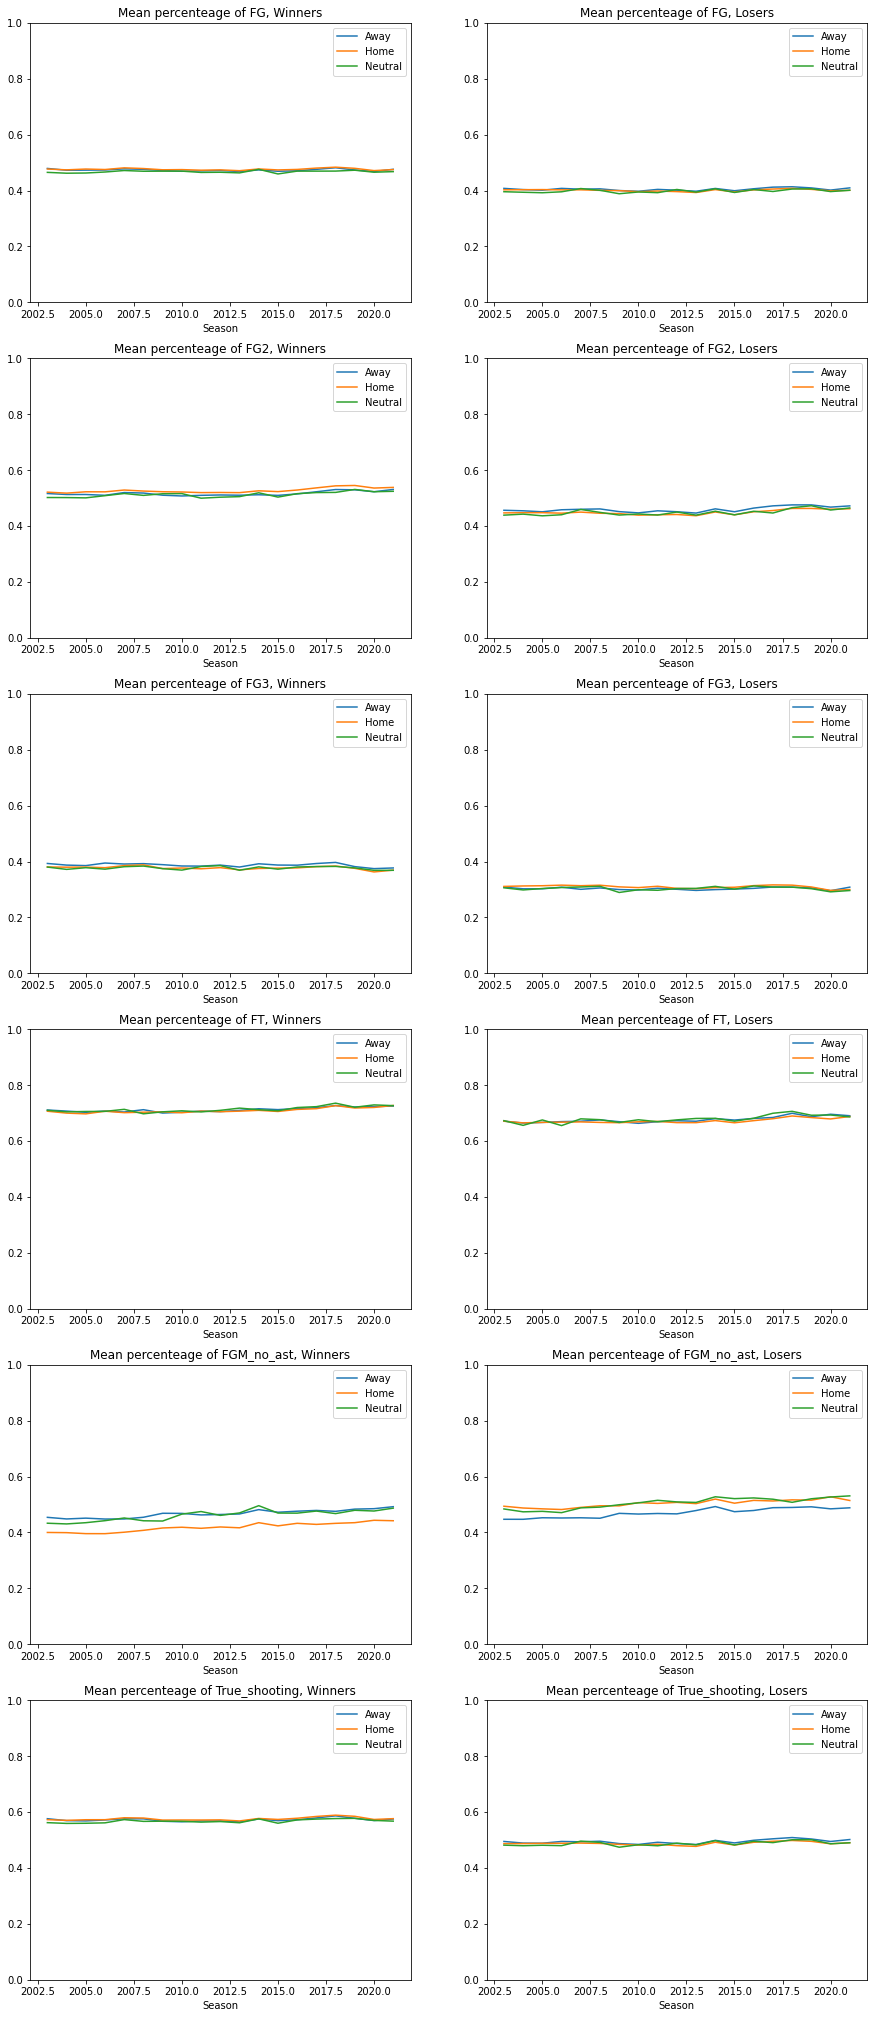

In [51]:
fig, ax= plt.subplots(6,2, figsize=(15, 6*6))

i = 0

for col in [c for c in summaries.columns if '_perc_mean' in c and c.startswith('W')]:
    name = col.split('_perc_')[0][1:]
    summaries[col].unstack().plot(title='Mean percenteage of '+name+', Winners',ax=ax[i][0])
    summaries['L'+name+'_perc_mean'].unstack().plot(title='Mean percenteage of '+name+', Losers',ax=ax[i][1])
    ax[i][0].legend(labels=['Away', 'Home', 'Neutral'])
    ax[i][1].legend(labels=['Away', 'Home', 'Neutral'])
    ax[i][0].set_ylim(0,1)
    ax[i][1].set_ylim(0,1)
    i += 1

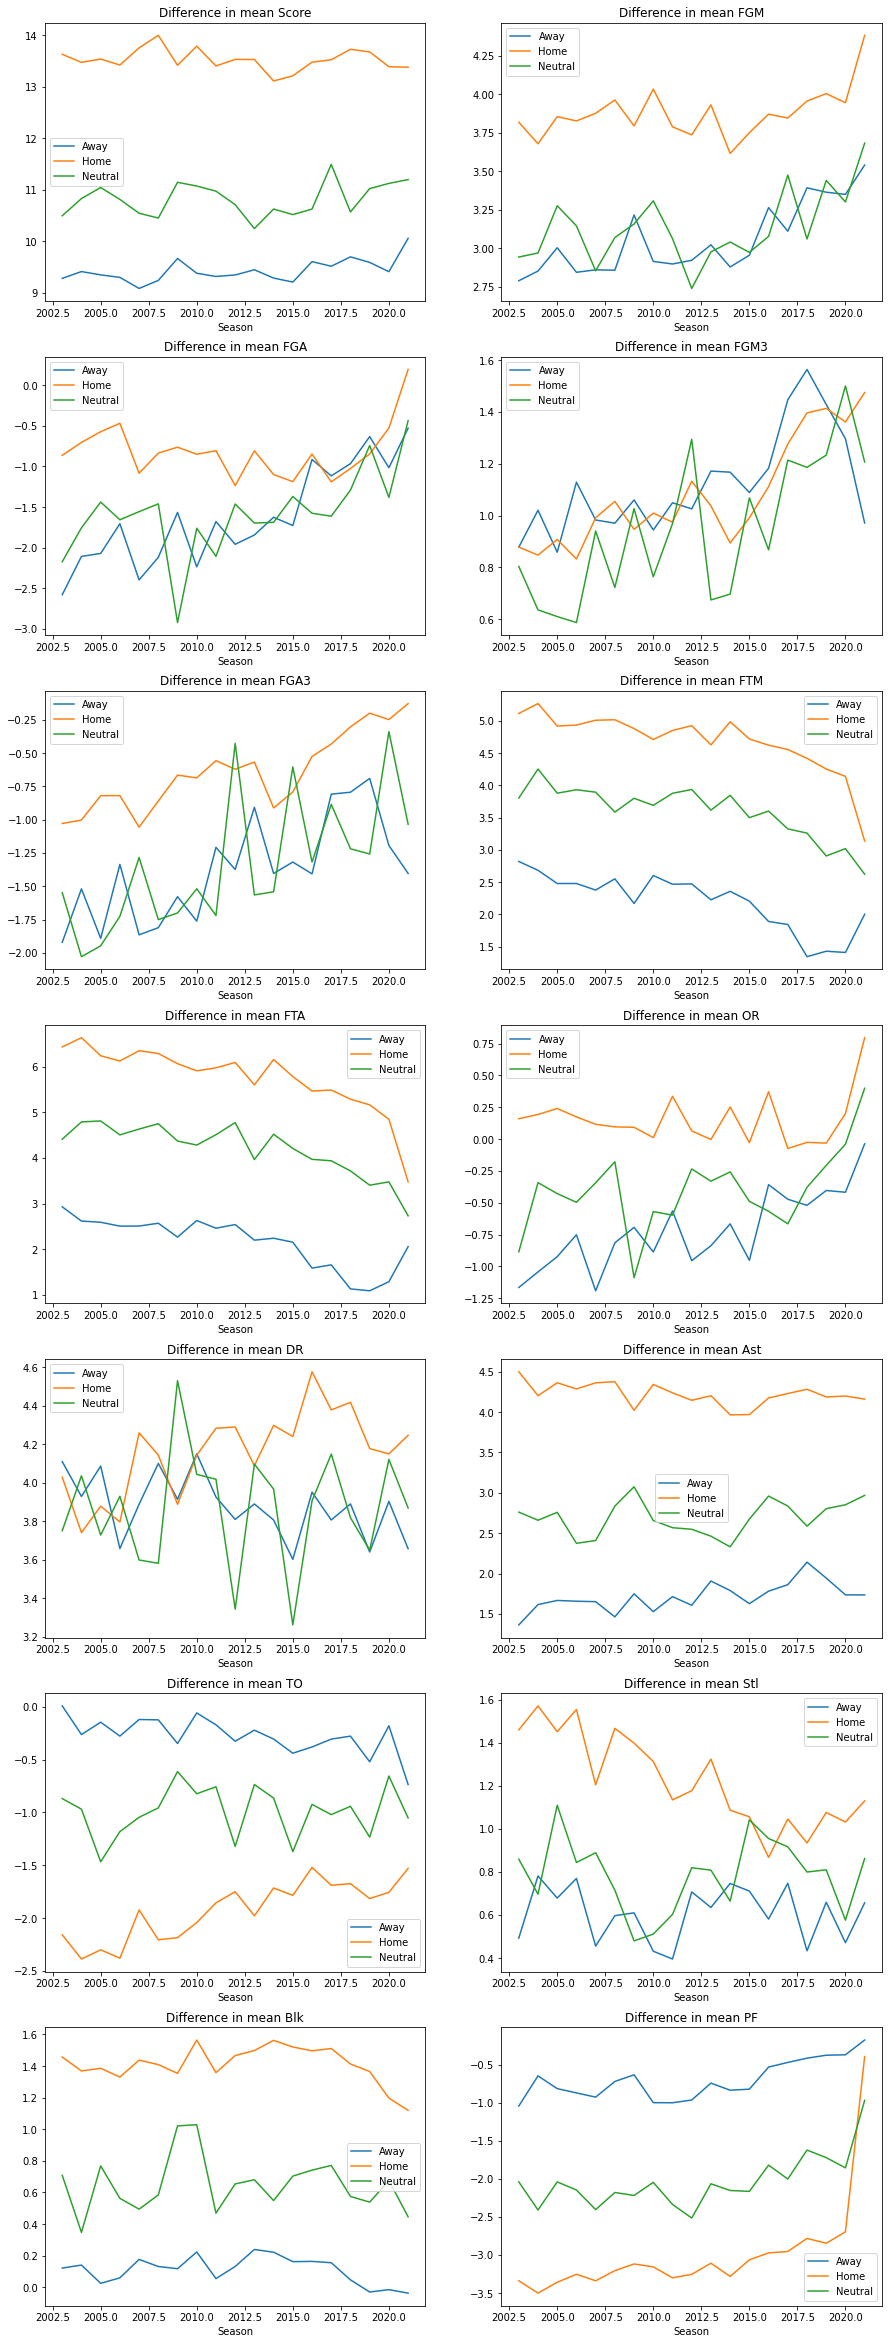

In [52]:
fig, ax= plt.subplots(7,2, figsize=(15, 6*7))

i, j = 0, 0

for col in stats:
    name = col[1:]
    summaries[[c for c in summaries.columns if name+'_diff_mean' in c]].unstack().plot(title='Difference in mean '+name,ax=ax[i][j])
    ax[i][j].legend(labels=['Away', 'Home', 'Neutral'])
    if j == 0:
        j = 1
    else:
        j = 0
        i += 1

In [54]:
playoff = pd.read_csv('data/raw_men/MDataFiles_Stage2/MNCAATourneyDetailedResults.csv')

playoff= process_details(playoff)

playoff.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF,WOT_win,WAway,WFG_perc,WFGM2,WFGA2,WFG2_perc,WFG3_perc,WFT_perc,WTot_Reb,WFGM_no_ast,WFGM_no_ast_perc,Wpossessions,Woff_rating,Wshtg_opportunity,WTO_perposs,WTrue_shooting_perc,LFG_perc,LFGM2,LFGA2,LFG2_perc,LFG3_perc,LFT_perc,LTot_Reb,LFGM_no_ast,LFGM_no_ast_perc,Lpossessions,Loff_rating,Lshtg_opportunity,LTO_perposs,LTrue_shooting_perc,Wdef_rating,Ldef_rating,Wopp_shtg_opportunity,Lopp_shtg_opportunity,Wopp_possessions,Lopp_possessions,Wopp_score,Lopp_score,Wopp_FTA,Wopp_FGA,Lopp_FTA,Lopp_FGA,Wimpact,Limpact,WDR_opportunity,LDR_opportunity,WOR_opportunity,LOR_opportunity,Score_diff,FGM_diff,FGA_diff,FGM3_diff,FGA3_diff,FTM_diff,FTA_diff,OR_diff,DR_diff,Ast_diff,TO_diff,Stl_diff,Blk_diff,PF_diff,FGM2_diff,FGA2_diff,Tot_Reb_diff,FGM_no_ast_diff,DR_opportunity_diff,OR_opportunity_diff,possessions_diff,off_rating_diff,def_rating_diff,shtg_opportunity_diff,TO_perposs_diff,impact_diff,True_shooting_perc_diff
0,2003,134,1421,92,1411,84,N,1,32,69,11,29,17,26,14,30,17,12,5,3,22,29,67,12,31,14,31,17,28,16,15,5,0,22,1,1,0.463768,21,40,0.525000,0.379310,0.653846,44,15,0.468750,79.350,115.942029,1.025205,0.151229,0.565458,0.432836,17,36,0.472222,0.387097,0.451613,45,13,0.448276,79.725,105.362183,1.025086,0.188147,0.513919,105.362183,115.942029,1.025086,1.025205,79.725,79.350,84,92,31,67,26,69,0.567114,0.432886,0.789474,0.756757,0.378378,0.447368,8,3,2,-1,-2,3,-5,-3,2,1,-3,0,3,0,4,4,-1,2,0.032717,-0.068990,-0.375,10.579846,-10.579846,0.000119,-0.036918,0.134228,0.051539
1,2003,136,1112,80,1436,51,N,0,31,66,7,23,11,14,11,36,22,16,10,7,8,20,64,4,16,7,7,8,26,12,17,10,3,15,0,1,0.469697,24,43,0.558140,0.304348,0.785714,47,9,0.290323,77.650,103.026401,0.935608,0.206053,0.550585,0.312500,16,48,0.333333,0.250000,1.000000,34,8,0.400000,76.325,66.819522,0.882083,0.222732,0.378760,66.819522,103.026401,0.882083,0.935608,76.325,77.650,51,80,7,64,14,66,0.709265,0.290735,0.818182,0.742857,0.314286,0.181818,29,11,2,3,7,4,7,3,10,10,-1,0,4,-7,8,-5,13,1,0.075325,0.132468,1.325,36.206879,-36.206879,0.053525,-0.016679,0.418530,0.171825
2,2003,136,1113,84,1272,71,N,0,31,59,6,14,16,22,10,27,18,9,7,4,19,25,69,7,28,14,21,20,22,11,12,2,5,18,0,1,0.525424,25,45,0.555556,0.428571,0.727273,37,13,0.419355,68.450,122.717312,1.014609,0.131483,0.604752,0.362319,18,41,0.439024,0.250000,0.666667,42,14,0.560000,70.975,100.035224,1.112716,0.169074,0.449509,100.035224,122.717312,1.112716,1.014609,70.975,68.450,71,84,21,69,22,59,0.645161,0.354839,0.613636,0.785714,0.357143,0.454545,13,6,-10,-1,-14,2,1,-10,5,7,-3,5,-1,1,7,4,-5,-1,-0.172078,-0.097403,-2.525,22.682088,-22.682088,-0.098107,-0.037591,0.290323,0.155242
3,2003,136,1141,79,1166,73,N,0,29,53,3,7,18,25,11,20,15,18,13,1,19,27,60,7,17,12,17,14,17,20,21,6,6,21,0,1,0.547170,26,46,0.565217,0.428571,0.720000,31,14,0.482759,71.875,109.913043,0.902609,0.250435,0.608863,0.450000,20,43,0.465116,0.411765,0.705882,31,7,0.259259,75.075,97.236097,0.906760,0.279720,0.536173,97.236097,109.913043,0.906760,0.902609,75.075,71.875,73,79,17,60,25,53,0.553333,0.446667,0.606061,0.708333,0.458333,0.424242,6,2,-7,-4,-10,6,8,-3,3,-5,-3,7,-5,-2,6,3,0,7,-0.102273,0.034091,-3.200,12.676946,-12.676946,-0.004151,-0.029285,0.106667,0.072690
4,2003,136,1143,76,1301,74,N,1,27,64,7,20,15,23,18,20,17,13,8,2,14,25,56,9,21,15,20,10,26,16,14,5,8,19,1,1,0.421875,20,44,0.454545,0.350000,0.652174,38,10,0.370370,69.925,108.687880,1.071505,0.185913,0.507174,0.446429,16,35,0.457143,0.428571,0.750000,36,9,0.360000,69.500,106.474820,0.942446,0.201439,0.564885,106.474820,108.687880,0.942446,1.071505,69.500,69.925,74,76,20,56,23,64,0.489796,0.510204,0.645161,0.702703,0.486486,0.322581,2,2,8,-2,-1,0,3,8,-6,1,-1,3,-6,-5,4,9,2,1,-0.057541,0.163906,0.425,2.213060,-2.213060,0.129059,-0.015525,-0.020408,-0.057712


In [55]:
not_sum = ['WTeamID', 'DayNum', 'LTeamID']
to_sum = [col for col in playoff.columns if col not in not_sum]

summaries = playoff[to_sum].groupby(['Season']).agg(['min', 'max', 'mean', 'median', 'count'])

summaries.columns = ['_'.join(col).strip() for col in summaries.columns.values]
summaries

,WScore_min,WScore_max,WScore_mean,WScore_median,WScore_count,LScore_min,LScore_max,LScore_mean,LScore_median,LScore_count,NumOT_min,NumOT_max,NumOT_mean,NumOT_median,NumOT_count,WFGM_min,WFGM_max,WFGM_mean,WFGM_median,WFGM_count,WFGA_min,WFGA_max,WFGA_mean,WFGA_median,WFGA_count,WFGM3_min,WFGM3_max,WFGM3_mean,WFGM3_median,WFGM3_count,WFGA3_min,WFGA3_max,WFGA3_mean,WFGA3_median,WFGA3_count,WFTM_min,WFTM_max,WFTM_mean,WFTM_median,WFTM_count,WFTA_min,WFTA_max,WFTA_mean,WFTA_median,WFTA_count,WOR_min,WOR_max,WOR_mean,WOR_median,WOR_count,WDR_min,WDR_max,WDR_mean,WDR_median,WDR_count,WAst_min,WAst_max,WAst_mean,WAst_median,WAst_count,WTO_min,WTO_max,WTO_mean,WTO_median,WTO_count,WStl_min,WStl_max,WStl_mean,WStl_median,WStl_count,WBlk_min,WBlk_max,WBlk_mean,WBlk_median,WBlk_count,WPF_min,WPF_max,WPF_mean,WPF_median,WPF_count,LFGM_min,LFGM_max,LFGM_mean,LFGM_median,LFGM_count,LFGA_min,LFGA_max,LFGA_mean,LFGA_median,LFGA_count,LFGM3_min,LFGM3_max,LFGM3_mean,LFGM3_median,LFGM3_count,LFGA3_min,LFGA3_max,LFGA3_mean,LFGA3_median,LFGA3_count,LFTM_min,LFTM_max,LFTM_mean,LFTM_median,LFTM_count,LFTA_min,LFTA_max,LFTA_mean,LFTA_median,LFTA_count,LOR_min,LOR_max,LOR_mean,LOR_median,LOR_count,LDR_min,LDR_max,LDR_mean,LDR_median,LDR_count,LAst_min,LAst_max,LAst_mean,LAst_median,LAst_count,LTO_min,LTO_max,LTO_mean,LTO_median,LTO_count,LStl_min,LStl_max,LStl_mean,LStl_median,LStl_count,LBlk_min,LBlk_max,LBlk_mean,LBlk_median,LBlk_count,LPF_min,LPF_max,LPF_mean,LPF_median,LPF_count,WOT_win_min,WOT_win_max,WOT_win_mean,WOT_win_median,WOT_win_count,...,LDR_opportunity_min,LDR_opportunity_max,LDR_opportunity_mean,LDR_opportunity_median,LDR_opportunity_count,WOR_opportunity_min,WOR_opportunity_max,WOR_opportunity_mean,WOR_opportunity_median,WOR_opportunity_count,LOR_opportunity_min,LOR_opportunity_max,LOR_opportunity_mean,LOR_opportunity_median,LOR_opportunity_count,Score_diff_min,Score_diff_max,Score_diff_mean,Score_diff_median,Score_diff_count,FGM_diff_min,FGM_diff_max,FGM_diff_mean,FGM_diff_median,FGM_diff_count,FGA_diff_min,FGA_diff_max,FGA_diff_mean,FGA_diff_median,FGA_diff_count,FGM3_diff_min,FGM3_diff_max,FGM3_diff_mean,FGM3_diff_median,FGM3_diff_count,FGA3_diff_min,FGA3_diff_max,FGA3_diff_mean,FGA3_diff_median,FGA3_diff_count,FTM_diff_min,FTM_diff_max,FTM_diff_mean,FTM_diff_median,FTM_diff_count,FTA_diff_min,FTA_diff_max,FTA_diff_mean,FTA_diff_median,FTA_diff_count,OR_diff_min,OR_diff_max,OR_diff_mean,OR_diff_median,OR_diff_count,DR_diff_min,DR_diff_max,DR_diff_mean,DR_diff_median,DR_diff_count,Ast_diff_min,Ast_diff_max,Ast_diff_mean,Ast_diff_median,Ast_diff_count,TO_diff_min,TO_diff_max,TO_diff_mean,TO_diff_median,TO_diff_count,Stl_diff_min,Stl_diff_max,Stl_diff_mean,Stl_diff_median,Stl_diff_count,Blk_diff_min,Blk_diff_max,Blk_diff_mean,Blk_diff_median,Blk_diff_count,PF_diff_min,PF_diff_max,PF_diff_mean,PF_diff_median,PF_diff_count,FGM2_diff_min,FGM2_diff_max,FGM2_diff_mean,FGM2_diff_median,FGM2_diff_count,FGA2_diff_min,FGA2_diff_max,FGA2_diff_mean,FGA2_diff_median,FGA2_diff_count,Tot_Reb_diff_min,Tot_Reb_diff_max,Tot_Reb_diff_mean,Tot_Reb_diff_median,Tot_Reb_diff_count,FGM_no_ast_diff_min,FGM_no_ast_diff_max,FGM_no_ast_diff_mean,FGM_no_ast_diff_median,FGM_no_ast_diff_count,DR_opportunity_diff_min,DR_opportunity_diff_max,DR_opportunity_diff_mean,DR_opportunity_diff_median,DR_opportunity_diff_count,OR_opportunity_diff_min,OR_opportunity_diff_max,OR_opportunity_diff_mean,OR_opportunity_diff_median,OR_opportunity_diff_count,possessions_diff_min,possessions_diff_max,possessions_diff_mean,possessions_diff_median,possessions_diff_count,off_rating_diff_min,off_rating_diff_max,off_rating_diff_mean,off_rating_diff_median,off_rating_diff_count,def_rating_diff_min,def_rating_diff_max,def_rating_diff_mean,def_rating_diff_median,def_rating_diff_count,shtg_opportunity_diff_min,shtg_opportunity_diff_max,shtg_opportunity_diff_mean,shtg_opportunity_diff_median,shtg_opportunity_diff_count,TO_perposs_diff_min,TO_perposs_diff_max,TO_perposs_diff_mean,TO_perposs_d

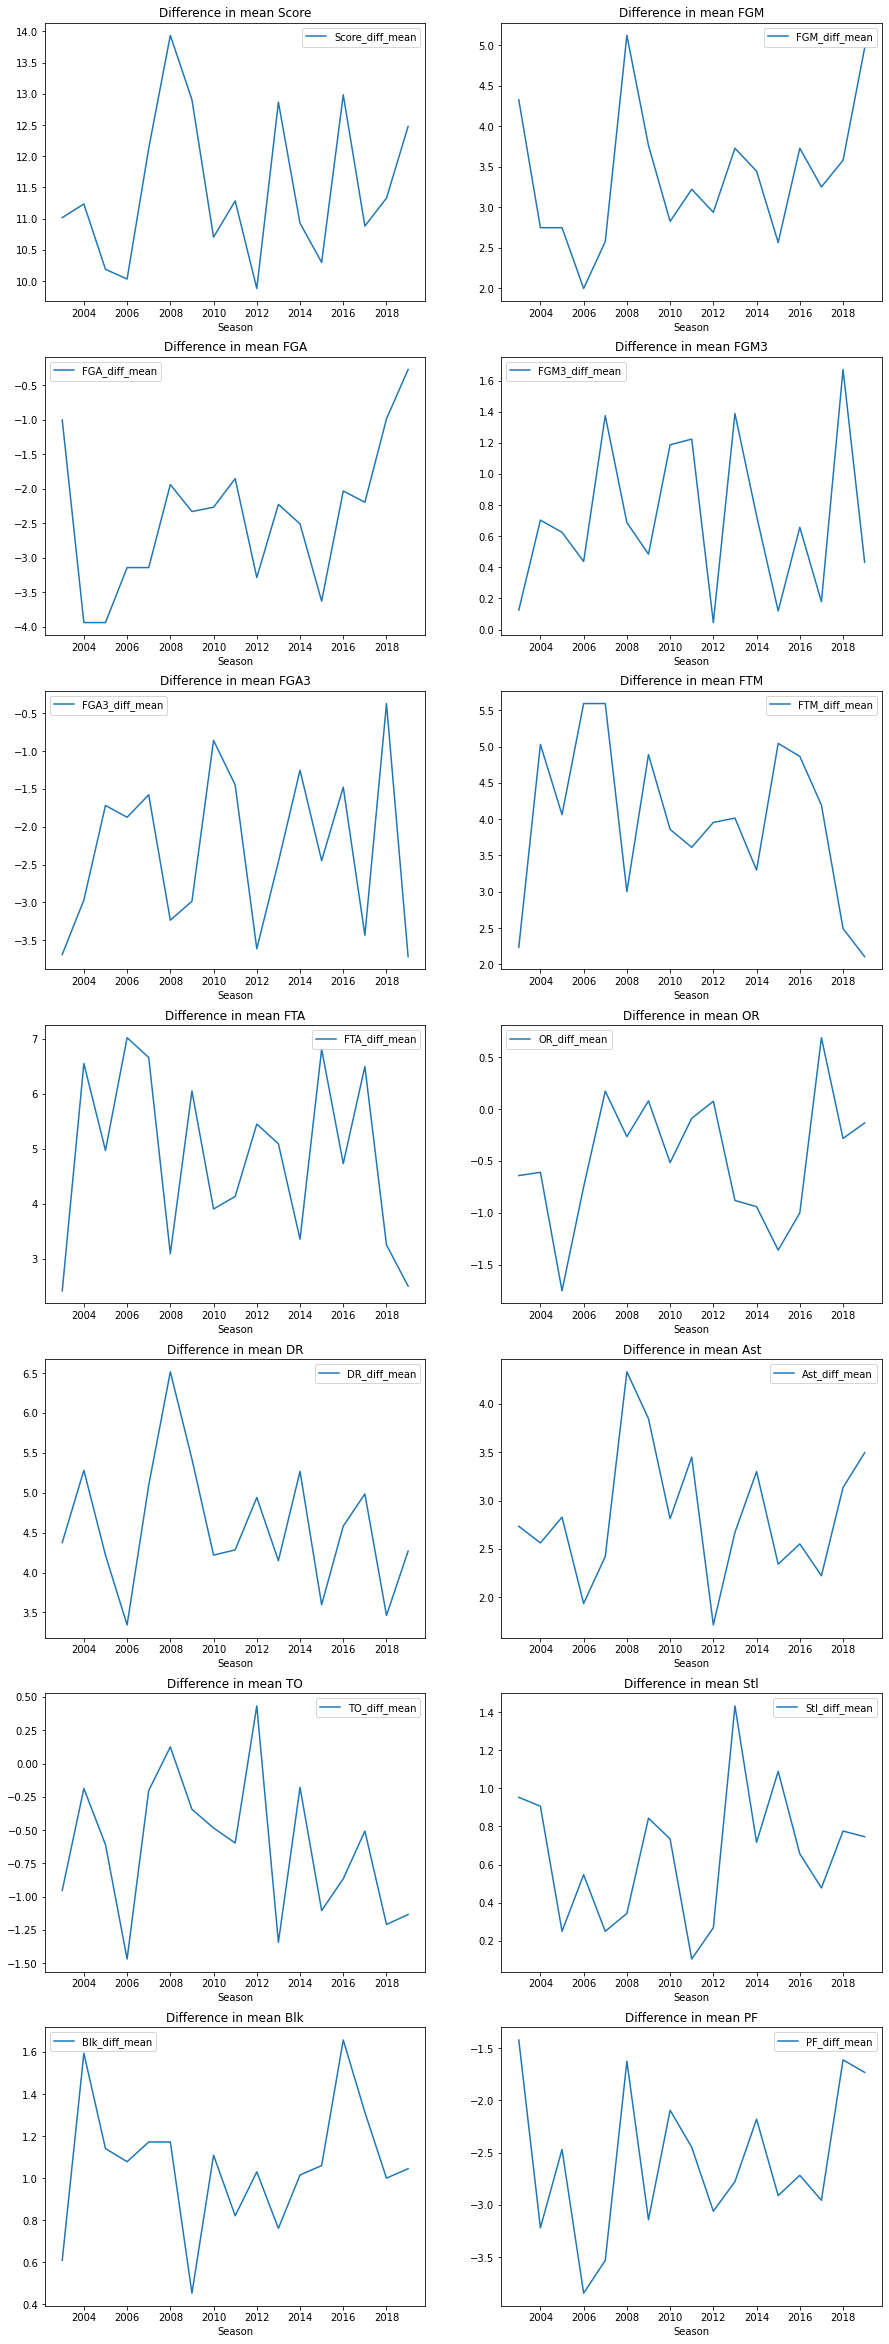

In [56]:
fig, ax= plt.subplots(7,2, figsize=(15, 6*7))

i, j = 0, 0

for col in stats:
    name = col[1:]
    summaries[[c for c in summaries.columns if name+'_diff_mean' in c]].plot(title='Difference in mean '+name,ax=ax[i][j])
    if j == 0:
        j = 1
    else:
        j = 0
        i += 1

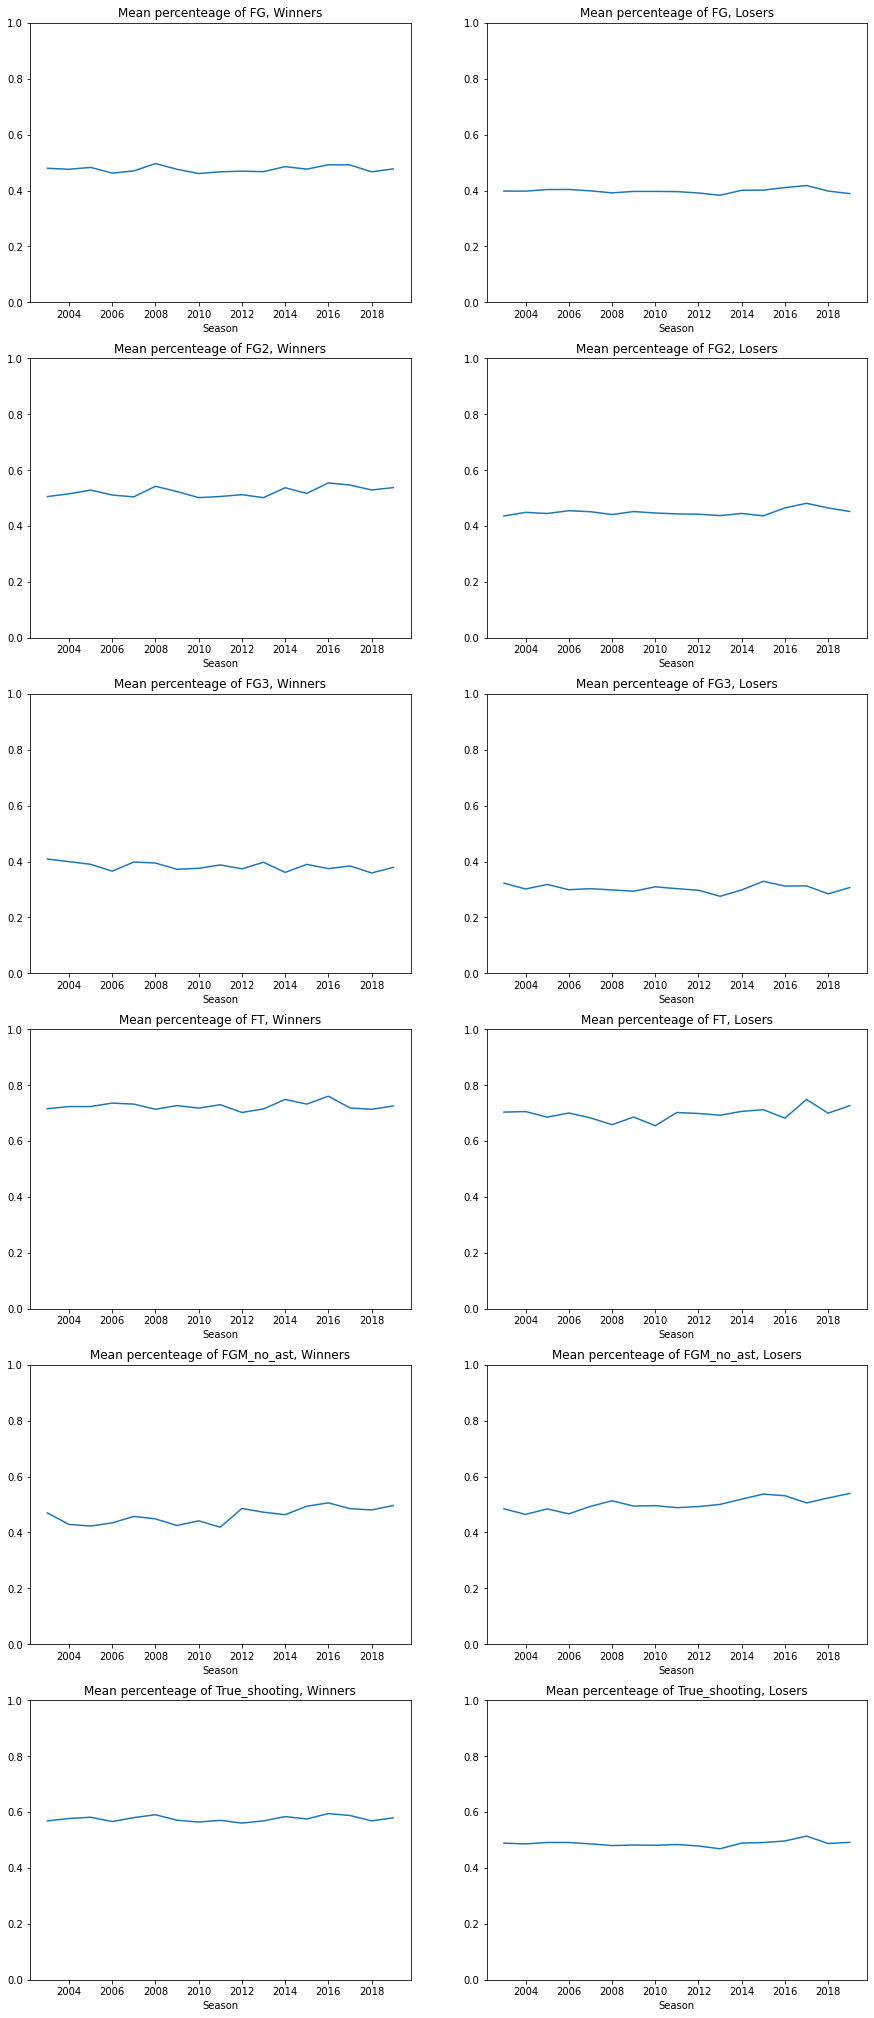

In [57]:
fig, ax= plt.subplots(6,2, figsize=(15, 6*6))

i = 0

for col in [c for c in summaries.columns if '_perc_mean' in c and c.startswith('W')]:
    name = col.split('_perc_')[0][1:]
    summaries[col].plot(title='Mean percenteage of '+name+', Winners',ax=ax[i][0])
    summaries['L'+name+'_perc_mean'].plot(title='Mean percenteage of '+name+', Losers',ax=ax[i][1])
    ax[i][0].set_ylim(0,1)
    ax[i][1].set_ylim(0,1)
    i += 1

# Seeds

In [58]:
[col for col in men_comp if 'Seed' in col]

['data/raw_men/M2021_Stage1/MNCAATourneySeeds.csv',
 'data/raw_men/M2021_Stage1/MNCAATourneySeedRoundSlots.csv',
 'data/raw_men/MDataFiles_Stage2/MNCAATourneySeeds.csv',
 'data/raw_men/MDataFiles_Stage2/MNCAATourneySeedRoundSlots.csv']

In [59]:
seeds = pd.read_csv('data/raw_men/MDataFiles_Stage2/MNCAATourneySeeds.csv')
seeds.head()

,Season,Seed,TeamID
0,1985,W01,1207
1,1985,W02,1210
2,1985,W03,1228
3,1985,W04,1260
4,1985,W05,1374


In [60]:
slots = pd.read_csv('data/raw_men/MDataFiles_Stage2/MNCAATourneySeedRoundSlots.csv')
slots.head()

,Seed,GameRound,GameSlot,EarlyDayNum,LateDayNum
0,W01,1,R1W1,136,137
1,W01,2,R2W1,138,139
2,W01,3,R3W1,143,144
3,W01,4,R4W1,145,146
4,W01,5,R5WX,152,152


# Rankings

In [61]:
[col for col in men_comp if 'Mass' in col]

['data/raw_men/M2021_Stage1/MMasseyOrdinals.csv',
 'data/raw_men/MDataFiles_Stage2/MMasseyOrdinals.csv']

In [62]:
massey = pd.read_csv('data/raw_men/MDataFiles_Stage2/MMasseyOrdinals.csv')
massey.head()

,Season,RankingDayNum,SystemName,TeamID,OrdinalRank
0,2003,35,SEL,1102,159
1,2003,35,SEL,1103,229
2,2003,35,SEL,1104,12
3,2003,35,SEL,1105,314
4,2003,35,SEL,1106,260


In [63]:
print(massey.SystemName.nunique())

184


In [64]:
tmp = massey[['Season', 'RankingDayNum', 'TeamID',
              'OrdinalRank']].groupby(['Season', 'TeamID',
                                       'RankingDayNum']).agg(['mean', 'max', 'min'])
tmp.columns = ['_'.join(col).strip() for col in tmp.columns.values]
tmp = tmp.reset_index()
tmp.head()

,Season,TeamID,RankingDayNum,OrdinalRank_mean,OrdinalRank_max,OrdinalRank_min
0,2003,1102,35,159.000000,159,159
1,2003,1102,37,118.000000,219,90
2,2003,1102,42,191.000000,191,191
3,2003,1102,43,108.000000,108,108
4,2003,1102,44,88.866667,153,52


In [65]:
tmp[tmp.OrdinalRank_mean != tmp.OrdinalRank_min]

,Season,TeamID,RankingDayNum,OrdinalRank_mean,OrdinalRank_max,OrdinalRank_min
1,2003,1102,37,118.000000,219,90
4,2003,1102,44,88.866667,153,52
6,2003,1102,51,133.052632,199,52
7,2003,1102,56,177.500000,184,173
8,2003,1102,57,148.470588,197,116
...,...,...,...,...,...,...
236507,2021,1471,107,277.454545,348,194
236508,2021,1471,114,266.893617,346,152
236509,2021,1471,121,274.739130,349,185
236510,2021,1471,128,253.591837,327,164


In [66]:
massey.RankingDayNum.max()

133

In [67]:
massey.TeamID.value_counts().head()

1115    14095
1181    13560
1242    13543
1314    13364
1277    13352
Name: TeamID, dtype: int64

# play by play

In [65]:
# [col for col in men_comp if 'Events' in col]

In [66]:
# pbp_event = pd.read_csv('data/raw_men/MEvents2020.csv')
# pbp_event.head()

In [67]:
#pbp_play = pd.read_csv('data/raw_men/MPlayers.csv')
#pbp_play.head()

# Putting things together

In [68]:
reg_season.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF,WOT_win,WAway,WFG_perc,WFGM2,WFGA2,WFG2_perc,WFG3_perc,WFT_perc,WTot_Reb,WFGM_no_ast,WFGM_no_ast_perc,Wpossessions,Woff_rating,Wshtg_opportunity,WTO_perposs,WTrue_shooting_perc,LFG_perc,LFGM2,LFGA2,LFG2_perc,LFG3_perc,LFT_perc,LTot_Reb,LFGM_no_ast,LFGM_no_ast_perc,Lpossessions,Loff_rating,Lshtg_opportunity,LTO_perposs,LTrue_shooting_perc,Wdef_rating,Ldef_rating,Wopp_shtg_opportunity,Lopp_shtg_opportunity,Wopp_possessions,Lopp_possessions,Wopp_score,Lopp_score,Wopp_FTA,Wopp_FGA,Lopp_FTA,Lopp_FGA,Wimpact,Limpact,WDR_opportunity,LDR_opportunity,WOR_opportunity,LOR_opportunity,Score_diff,FGM_diff,FGA_diff,FGM3_diff,FGA3_diff,FTM_diff,FTA_diff,OR_diff,DR_diff,Ast_diff,TO_diff,Stl_diff,Blk_diff,PF_diff,FGM2_diff,FGA2_diff,Tot_Reb_diff,FGM_no_ast_diff,DR_opportunity_diff,OR_opportunity_diff,possessions_diff,off_rating_diff,def_rating_diff,shtg_opportunity_diff,TO_perposs_diff,impact_diff,True_shooting_perc_diff
0,2003,10,1104,68,1328,62,N,0,27,58,3,14,11,18,14,24,13,23,7,1,22,22,53,2,10,16,22,10,22,8,18,9,2,20,0,1,0.465517,24,44,0.545455,0.214286,0.611111,38,14,0.518519,75.550,90.006618,0.880874,0.304434,0.510894,0.415094,20,43,0.465116,0.200000,0.727273,32,14,0.636364,71.450,86.773968,0.888034,0.251924,0.488574,86.773968,90.006618,0.888034,0.880874,71.450,75.550,62,68,22,53,18,58,0.543379,0.456621,0.774194,0.709677,0.451613,0.322581,6,5,5,1,4,-5,-4,4,2,5,5,-2,-1,2,4,1,6,0,0.064516,0.129032,4.100,3.232650,-3.232650,-0.007160,0.052510,0.086758,0.022320
1,2003,10,1272,70,1393,63,N,0,26,62,8,20,10,19,15,28,16,13,4,4,18,24,67,6,24,9,20,20,25,7,12,8,6,16,0,1,0.419355,18,42,0.428571,0.400000,0.526316,43,10,0.384615,69.025,101.412532,1.028975,0.188338,0.492784,0.358209,18,43,0.418605,0.250000,0.450000,45,17,0.708333,68.500,91.970803,1.116788,0.175182,0.411765,91.970803,101.412532,1.116788,1.028975,68.500,69.025,63,70,20,67,19,62,0.583710,0.416290,0.651163,0.694444,0.416667,0.465116,7,2,-5,2,-4,1,-1,-5,3,9,1,-4,-2,2,0,-1,-2,-7,-0.043282,-0.048450,0.525,9.441729,-9.441729,-0.087813,0.013155,0.167421,0.081020
2,2003,11,1266,73,1437,61,N,0,24,58,8,18,17,29,17,26,15,10,5,2,25,22,73,3,26,14,23,31,22,9,12,2,5,23,0,1,0.413793,16,40,0.400000,0.444444,0.586207,43,9,0.375000,64.775,112.697800,1.108066,0.154381,0.508534,0.301370,19,47,0.404255,0.115385,0.608696,53,13,0.590909,64.925,93.954563,1.292645,0.184829,0.363420,93.954563,112.697800,1.292645,1.108066,64.925,64.775,61,73,23,73,29,58,0.664740,0.335260,0.509804,0.647059,0.500000,0.607843,12,2,-15,5,-8,3,6,-14,4,6,-2,3,-3,2,-3,-7,-10,-4,-0.137255,-0.107843,-0.150,18.743237,-18.743237,-0.184579,-0.030448,0.329480,0.145114
3,2003,11,1296,56,1457,50,N,0,18,38,3,9,17,31,6,19,11,12,14,2,18,18,49,6,22,8,15,17,20,9,19,4,3,23,0,1,0.473684,15,29,0.517241,0.333333,0.548387,25,7,0.388889,58.725,95.359728,0.897829,0.204342,0.531057,0.367347,12,27,0.444444,0.272727,0.533333,37,9,0.500000,58.125,86.021505,0.965591,0.326882,0.445434,86.021505,95.359728,0.965591,0.897829,58.125,58.725,50,56,15,49,31,38,0.619048,0.380952,0.612903,1.000000,0.300000,0.548387,6,0,-11,-3,-13,9,16,-11,-1,2,-7,10,-1,-5,3,2,-12,-2,-0.387097,-0.248387,0.600,9.338222,-9.338222,-0.067763,-0.122539,0.238095,0.085623
4,2003,11,1400,77,1208,71,N,0,30,61,6,14,11,13,17,22,12,14,4,4,20,24,62,6,16,17,27,21,15,12,10,7,1,14,0,1,0.491803,24,47,0.510638,0.428571,0.846154,39,18,0.600000,64.175,119.984418,1.046747,0.218153,0.573130,0.387097,18,46,0.391304,0.375000,0.629630,36,12,0.500000,63.825,111.241676,1.172346,0.156678,0.474440,111.241676,119.984418,1.172346,1.046747,63.825,64.175,71,77,27,62,13,61,0.573123,0.426877,0.578947,0.483871,0.548387,0.552632,6,6,-1,0,-2,-6,-14,-4,7,0,4,-3,3,6,6,1,3,6,0.095076,-0.004244,0.350,8.742741,-8.742741,-0.125599,0.061475,0.146245,0.098690


In [69]:
reg_s = full_stats(reg_season)
reg_s.head()

,Season,TeamID,Ast,Ast_diff,Away,Blk,Blk_diff,DR,DR_diff,DR_opportunity,DR_opportunity_diff,FGA,FGA2,FGA2_diff,FGA3,FGA3_diff,FGA_diff,FGM,FGM2,FGM2_diff,FGM3,FGM3_diff,FGM_diff,FGM_no_ast,FGM_no_ast_diff,FTA,FTA_diff,FTM,FTM_diff,N_wins,OR,OR_diff,OR_opportunity,OR_opportunity_diff,OT_win,PF,PF_diff,Score,Score_diff,Stl,Stl_diff,TO,TO_diff,TO_perposs,TO_perposs_diff,Tot_Reb,Tot_Reb_diff,True_shooting_perc_diff,def_rating,def_rating_diff,impact,impact_diff,off_rating,off_rating_diff,opp_FGA,opp_FTA,opp_possessions,opp_score,opp_shtg_opportunity,possessions,possessions_diff,shtg_opportunity,shtg_opportunity_diff,FGM_perc,FGM2_perc,FGM3_perc,FT_perc,FGM_no_ast_perc,True_shooting_perc,Opp_True_shooting_perc,OT_win_perc
0,2003,1102,13.000000,3.857143,0.107143,1.785714,0.214286,16.821429,-3.321429,0.729546,-0.269979,39.785714,18.964286,-11.035714,20.821429,8.392857,-2.642857,19.142857,11.321429,-3.214286,7.821429,3.071429,-0.142857,6.142857,-4.000000,17.107143,-2.142857,11.142857,-2.535714,0.428571,4.178571,-5.428571,0.199280,-0.220372,0.000000,18.750000,0.392857,57.250000,0.250000,5.964286,0.535714,11.428571,-1.535714,0.205098,-0.031433,21.000000,-8.750000,0.043542,103.815398,0.060681,0.487043,-0.025913,103.754717,-0.060681,42.428571,19.250000,54.929464,57.000000,0.938488,55.161607,0.232143,0.871611,-0.066878,0.481149,0.596987,0.375643,0.651357,0.320896,0.597454,0.552622,0.00
1,2003,1103,15.222222,-0.259259,0.148148,2.333333,-0.518519,19.925926,-2.111111,0.684811,-0.091868,55.851852,39.777778,1.148148,16.074074,-2.296296,-1.148148,27.148148,21.703704,0.592593,5.444444,-1.222222,-0.629630,11.925926,-0.370370,25.851852,3.703704,19.037037,3.111111,0.481481,9.777778,-2.259259,0.338522,-0.071823,0.111111,19.851852,-2.592593,78.777778,0.629630,7.259259,0.851852,12.629630,-2.703704,0.179353,-0.036142,29.703704,-4.370370,-0.004515,110.627622,0.062489,0.498574,-0.002852,110.565133,-0.062489,57.000000,22.148148,70.816667,78.148148,0.953258,70.983333,0.166667,0.958632,0.005374,0.486074,0.545624,0.338710,0.736390,0.439291,0.578131,0.578701,0.75
2,2003,1104,12.107143,0.428571,0.142857,3.785714,0.607143,23.928571,1.285714,0.745133,0.052238,57.178571,37.321429,0.964286,19.857143,0.714286,1.678571,24.035714,17.678571,0.785714,6.357143,0.000000,0.785714,11.928571,0.357143,20.928571,3.785714,14.857143,2.714286,0.607143,13.571429,2.678571,0.406872,0.066526,0.035714,18.035714,-1.214286,69.285714,4.285714,6.607143,1.071429,13.285714,-0.571429,0.199076,-0.008115,37.500000,3.964286,0.002625,98.055068,-5.314906,0.527160,0.054319,103.369974,5.314906,55.500000,17.142857,66.607143,65.000000,0.955989,66.833929,0.226786,1.003595,0.047606,0.420362,0.473684,0.320144,0.709898,0.496285,0.516136,0.510662,1.00
3,2003,1105,14.538462,-1.269231,0.076923,2.076923,-2.115385,23.115385,-3.269231,0.728313,0.015613,61.615385,40.846154,-0.576923,20.769231,3.230769,2.653846,24.384615,16.807692,-3.923077,7.576923,1.307692,-2.615385,9.846154,-1.346154,21.846154,-2.653846,15.423077,-0.961538,0.269231,13.500000,0.307692,0.361851,-0.047139,0.000000,20.230769,1.153846,71.769231,-4.884615,9.307692,-0.076923,18.653846,-0.153846,0.240928,-0.005085,36.615385,-2.961538,-0.044502,100.981886,7.982712,0.444964,-0.110071,92.999174,-7.982712,58.961538,24.500000,76.214423,76.653846,0.927779,77.146154,0.931731,0.934529,0.006750,0.395755,0.411488,0.364815,0.705986,0.403785,0.498451,0.542882,0.00
4,2003,1106,11.678571,-0.107143,0.178571,3.142857,-0.035714,23.857143,1.500000,0.758479,0.049761,55.285714,37.642857,-0.535714,17.642857,2.428571,1.892857,23.428571,17.321429,0.392857,6.107143,1.321429,1.714286,11.750000,1.821429,16.464286,-5.500000,10.642857,-4.892857,0.464286,12.285714,0.964286,0.386003,0.029799,0.035714,18.178571,2.035714,63.607143,-0.142857,8.357143,-0.428571,17.035714,1.964286,0.250859,0.027558,36.142857,2.464286,0.004591,94.460182,0.811962,0.506812,0.013623,93.648220,-0.811962,53.392857,21.964286,67.575893,63.750000,0.945280,67.856250,0.280357,0.932234,-0.013046,0.423773,0.460152,

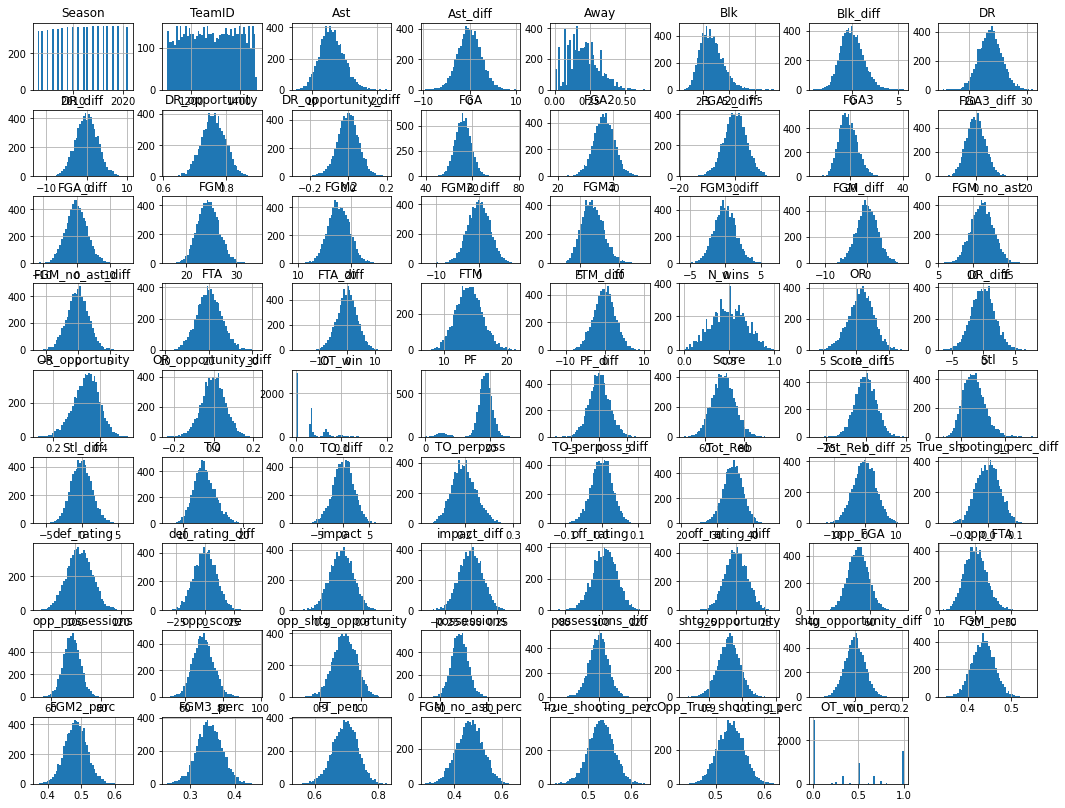

In [70]:
reg_s.hist(bins=50, figsize=(18, 14))
plt.show()

In [71]:
summary_reg = reg_s.groupby('Season')[[col for col in reg_s if col not in ['TeamID', 'Season']]].agg(['mean', 'max', 'min'])
summary_reg.columns = ['_'.join(col).strip() for col in summary_reg.columns.values]
summary_reg

,Ast_mean,Ast_max,Ast_min,Ast_diff_mean,Ast_diff_max,Ast_diff_min,Away_mean,Away_max,Away_min,Blk_mean,Blk_max,Blk_min,Blk_diff_mean,Blk_diff_max,Blk_diff_min,DR_mean,DR_max,DR_min,DR_diff_mean,DR_diff_max,DR_diff_min,DR_opportunity_mean,DR_opportunity_max,DR_opportunity_min,DR_opportunity_diff_mean,DR_opportunity_diff_max,DR_opportunity_diff_min,FGA_mean,FGA_max,FGA_min,FGA2_mean,FGA2_max,FGA2_min,FGA2_diff_mean,FGA2_diff_max,FGA2_diff_min,FGA3_mean,FGA3_max,FGA3_min,FGA3_diff_mean,FGA3_diff_max,FGA3_diff_min,FGA_diff_mean,FGA_diff_max,FGA_diff_min,FGM_mean,FGM_max,FGM_min,FGM2_mean,FGM2_max,FGM2_min,FGM2_diff_mean,FGM2_diff_max,FGM2_diff_min,FGM3_mean,FGM3_max,FGM3_min,FGM3_diff_mean,FGM3_diff_max,FGM3_diff_min,FGM_diff_mean,FGM_diff_max,FGM_diff_min,FGM_no_ast_mean,FGM_no_ast_max,FGM_no_ast_min,FGM_no_ast_diff_mean,FGM_no_ast_diff_max,FGM_no_ast_diff_min,FTA_mean,FTA_max,FTA_min,FTA_diff_mean,FTA_diff_max,FTA_diff_min,FTM_mean,FTM_max,FTM_min,FTM_diff_mean,FTM_diff_max,FTM_diff_min,N_wins_mean,N_wins_max,N_wins_min,OR_mean,OR_max,OR_min,OR_diff_mean,OR_diff_max,OR_diff_min,OR_opportunity_mean,OR_opportunity_max,OR_opportunity_min,OR_opportunity_diff_mean,OR_opportunity_diff_max,OR_opportunity_diff_min,OT_win_mean,OT_win_max,OT_win_min,PF_mean,PF_max,PF_min,PF_diff_mean,PF_diff_max,PF_diff_min,Score_mean,Score_max,Score_min,Score_diff_mean,Score_diff_max,Score_diff_min,Stl_mean,Stl_max,Stl_min,Stl_diff_mean,Stl_diff_max,Stl_diff_min,TO_mean,TO_max,TO_min,TO_diff_mean,TO_diff_max,TO_diff_min,TO_perposs_mean,TO_perposs_max,TO_perposs_min,TO_perposs_diff_mean,TO_perposs_diff_max,TO_perposs_diff_min,Tot_Reb_mean,Tot_Reb_max,Tot_Reb_min,Tot_Reb_diff_mean,Tot_Reb_diff_max,Tot_Reb_diff_min,True_shooting_perc_diff_mean,True_shooting_perc_diff_max,True_shooting_perc_diff_min,def_rating_mean,def_rating_max,def_rating_min,def_rating_diff_mean,def_rating_diff_max,def_rating_diff_min,impact_mean,impact_max,impact_min,impact_diff_mean,impact_diff_max,impact_diff_min,off_rating_mean,off_rating_max,off_rating_min,off_rating_diff_mean,off_rating_diff_max,off_rating_diff_min,opp_FGA_mean,opp_FGA_max,opp_FGA_min,opp_FTA_mean,opp_FTA_max,opp_FTA_min,opp_possessions_mean,opp_possessions_max,opp_possessions_min,opp_score_mean,opp_score_max,opp_score_min,opp_shtg_opportunity_mean,opp_shtg_opportunity_max,opp_shtg_opportunity_min,possessions_mean,possessions_max,possessions_min,possessions_diff_mean,possessions_diff_max,possessions_diff_min,shtg_opportunity_mean,shtg_opportunity_max,shtg_opportunity_min,shtg_opportunity_diff_mean,shtg_opportunity_diff_max,shtg_opportunity_diff_min,FGM_perc_mean,FGM_perc_max,FGM_perc_min,FGM2_perc_mean,FGM2_perc_max,FGM2_perc_min,FGM3_perc_mean,FGM3_perc_max,FGM3_perc_min,FT_perc_mean,FT_perc_max,FT_perc_min,FGM_no_ast_perc_mean,FGM_no_ast_perc_max,FGM_no_ast_perc_min,True_shooting_perc_mean,True_shooting_perc_max,True_shooting_perc_min,Opp_True_shooting_perc_mean,Opp_True_shooting_perc_max,Opp_True_shooting_perc_min,OT_win_perc_mean,OT_win_perc_max,OT_win_perc_min
Season,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2003,13.552585,18.892857,9.115385,-0.052070,7.233333,-8.200000,0.193011,0.551724,0.0,3.244834,7.733333,0.655172,-0.020800,4.137931,-3.730769,23.101065,28.375000,16.821429,-0.053883,7.586207,-7.357143,0.741416,0.824313,0.644698,-0.000727,0.130514,-0.269979,56.093181,67.925926,39.785714,38.041942,50.400000,18.964286,-0.020892,12.666667,-13.833333,18.051239,28.555556,9.740741,-0.000199,11.111111,-8.928571,-0.021090,10.666667,-10.916667,24.550438,30.321429,16.925926,18.295494,25.433333,11.321429,-0.050123,7.466667,-7.000000,6.254943,10.074074,2.518519,-0.013235,3.642857,-3.703704,-0.063358,6.766667,-6.642857,10.997852,15.433333,6.074074,-0.011288,7.800000,-4.862069,20.621980,28.846154,12.714286,-0.058898,10.300000,-18.296296,14.324645,20.034483,8.60

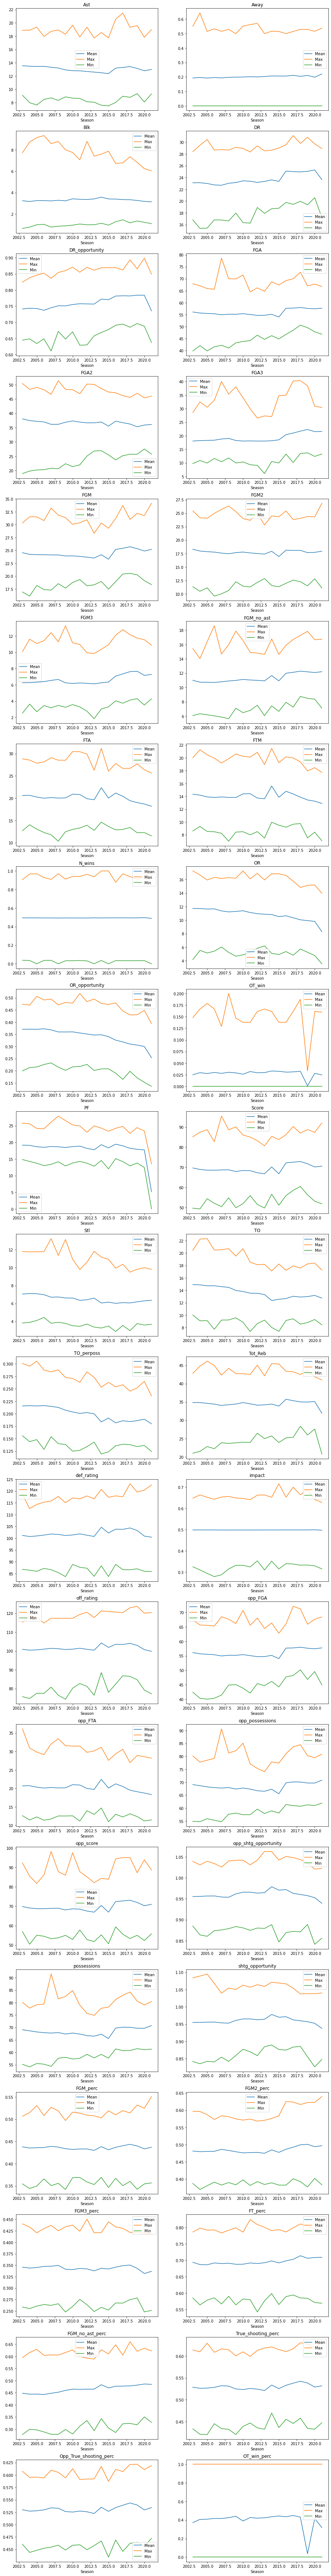

In [72]:
stats = [col.split('_mean')[0] for col in summary_reg if '_mean' in col and 'diff_' not in col and 'advantage' not in col]

fig, ax= plt.subplots(int(np.ceil(len(stats)/2)),2, figsize=(15, 6*int(np.ceil(len(stats)/2))))

i, j = 0, 0

for col in stats:
    summary_reg[[col+'_mean', col+'_max', col+'_min']].plot(title=col,ax=ax[i][j])
    ax[i][j].legend(labels=['Mean', 'Max', 'Min'])
    if j == 0:
        j = 1
    else:
        j = 0
        i += 1

plt.show()

# Exploring training data (from Notebook 3)

In [75]:
df = pd.read_csv('data/processed_men/training_data.csv')

df.head()

,Season,DayNum,Team1,Team2,target,target_points,T1_Loc,T2_Loc,ID,T1_Ast,T1_Ast_advantage,T1_Ast_diff,T1_Away,T1_Blk,T1_Blk_advantage,T1_Blk_diff,T1_DR,T1_DR_advantage,T1_DR_diff,T1_DR_opportunity,T1_DR_opportunity_advantage,T1_DR_opportunity_diff,T1_FGA,T1_FGA2,T1_FGA2_advantage,T1_FGA2_diff,T1_FGA3,T1_FGA3_advantage,T1_FGA3_diff,T1_FGA_advantage,T1_FGA_diff,T1_FGM,T1_FGM2,T1_FGM2_advantage,T1_FGM2_diff,T1_FGM3,T1_FGM3_advantage,T1_FGM3_diff,T1_FGM_advantage,T1_FGM_diff,T1_FGM_no_ast,T1_FGM_no_ast_advantage,T1_FGM_no_ast_diff,T1_FTA,T1_FTA_advantage,T1_FTA_diff,T1_FTM,T1_FTM_advantage,T1_FTM_diff,T1_N_wins,T1_OR,T1_OR_advantage,T1_OR_diff,T1_OR_opportunity,T1_OR_opportunity_advantage,T1_OR_opportunity_diff,T1_OT_win,T1_PF,T1_PF_advantage,T1_PF_diff,T1_Score,T1_Score_advantage,T1_Score_diff,T1_Stl,T1_Stl_advantage,T1_Stl_diff,T1_TO,T1_TO_advantage,T1_TO_diff,T1_TO_perposs,T1_TO_perposs_advantage,T1_TO_perposs_diff,T1_Tot_Reb,T1_Tot_Reb_advantage,T1_Tot_Reb_diff,T1_True_shooting_perc_advantage,T1_True_shooting_perc_diff,T1_def_rating,T1_def_rating_advantage,T1_def_rating_diff,T1_impact,T1_impact_advantage,T1_impact_diff,T1_off_rating,T1_off_rating_advantage,T1_off_rating_diff,T1_opp_FGA,T1_opp_FTA,T1_opp_possessions,T1_opp_score,T1_opp_shtg_opportunity,T1_possessions,T1_possessions_advantage,T1_possessions_diff,T1_shtg_opportunity,T1_shtg_opportunity_advantage,T1_shtg_opportunity_diff,T1_top_team,T1_upset,T1_FGM_perc,T1_FGM2_perc,T1_FGM3_perc,T1_FT_perc,T1_FGM_no_ast_perc,T1_True_shooting_perc,T1_Opp_True_shooting_perc,T1_OT_win_perc,T1_Seed,T1_Rank,T2_Ast,T2_Ast_advantage,T2_Ast_diff,T2_Away,T2_Blk,T2_Blk_advantage,T2_Blk_diff,T2_DR,T2_DR_advantage,T2_DR_diff,T2_DR_opportunity,T2_DR_opportunity_advantage,T2_DR_opportunity_diff,T2_FGA,T2_FGA2,T2_FGA2_advantage,T2_FGA2_diff,T2_FGA3,T2_FGA3_advantage,T2_FGA3_diff,T2_FGA_advantage,T2_FGA_diff,T2_FGM,T2_FGM2,T2_FGM2_advantage,T2_FGM2_diff,T2_FGM3,T2_FGM3_advantage,T2_FGM3_diff,T2_FGM_advantage,T2_FGM_diff,T2_FGM_no_ast,T2_FGM_no_ast_advantage,T2_FGM_no_ast_diff,T2_FTA,T2_FTA_advantage,T2_FTA_diff,T2_FTM,T2_FTM_advantage,T2_FTM_diff,T2_N_wins,...,T2_TO_diff,T2_TO_perposs,T2_TO_perposs_advantage,T2_TO_perposs_diff,T2_Tot_Reb,T2_Tot_Reb_advantage,T2_Tot_Reb_diff,T2_True_shooting_perc_advantage,T2_True_shooting_perc_diff,T2_def_rating,T2_def_rating_advantage,T2_def_rating_diff,T2_impact,T2_impact_advantage,T2_impact_diff,T2_off_rating,T2_off_rating_advantage,T2_off_rating_diff,T2_opp_FGA,T2_opp_FTA,T2_opp_possessions,T2_opp_score,T2_opp_shtg_opportunity,T2_possessions,T2_possessions_advantage,T2_possessions_diff,T2_shtg_opportunity,T2_shtg_opportunity_advantage,T2_shtg_opportunity_diff,T2_top_team,T2_upset,T2_FGM_perc,T2_FGM2_perc,T2_FGM3_perc,T2_FT_perc,T2_FGM_no_ast_perc,T2_True_shooting_perc,T2_Opp_True_shooting_perc,T2_OT_win_perc,T2_Seed,T2_Rank,delta_Loc,delta_Ast,delta_Ast_advantage,delta_Ast_diff,delta_Away,delta_Blk,delta_Blk_advantage,delta_Blk_diff,delta_DR,delta_DR_advantage,delta_DR_diff,delta_DR_opportunity,delta_DR_opportunity_advantage,delta_DR_opportunity_diff,delta_FGA,delta_FGA2,delta_FGA2_advantage,delta_FGA2_diff,delta_FGA3,delta_FGA3_advantage,delta_FGA3_diff,delta_FGA_advantage,delta_FGA_diff,delta_FGM,delta_FGM2,delta_FGM2_advantage,delta_FGM2_diff,delta_FGM3,delta_FGM3_advantage,delta_FGM3_diff,delta_FGM_advantage,delta_FGM_diff,delta_FGM_no_ast,delta_FGM_no_ast_advantage,delta_FGM_no_ast_diff,delta_FTA,delta_FTA_advantage,delta_FTA_diff,delta_FTM,delta_FTM_advantage,delta_FTM_diff,delta_N_wins,delta_OR,delta_OR_advantage,delta_OR_diff,delta_OR_opportunity,delta_OR_opportunity_advantage,delta_OR_opportunity_diff,delta_OT_win,delta_PF,delta_PF_advantage,delta_PF_diff,delta_Score,delta_Score_advantage,delta_Score_diff,delta_Stl,delta_Stl_advantage,delta_Stl_diff,delta_TO,delta_TO_advantage,delta_TO_diff,delta_TO_perposs,delta_TO_perposs_advantage,delta_TO_perposs_diff,delta_Tot_Reb,delta_Tot_Reb_advantage,delta_Tot_Reb_diff,delta_True_shooting_perc_advantage,delta

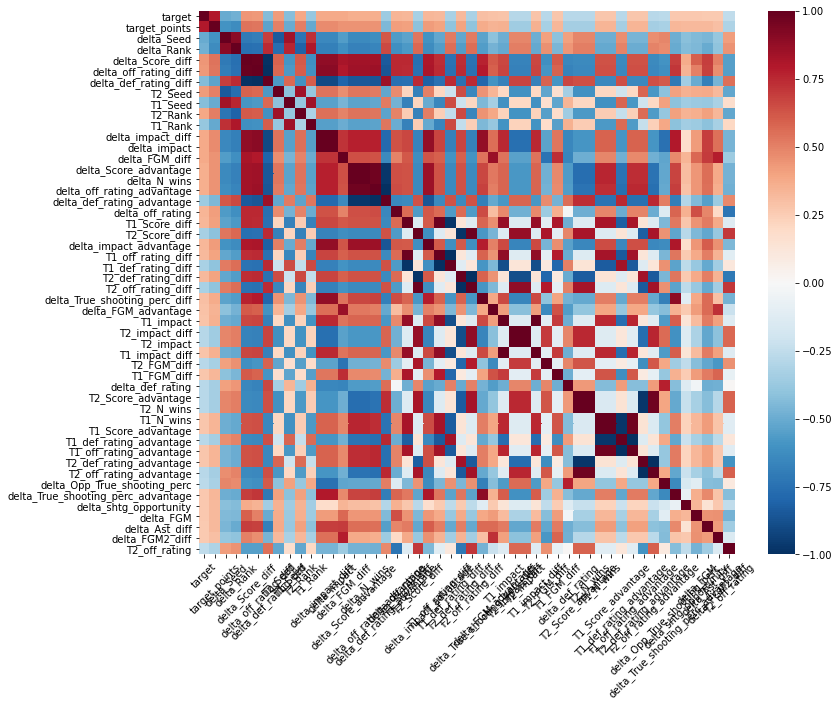

In [76]:
high_corr = tml.plot_correlations(df, target='target', limit=50)

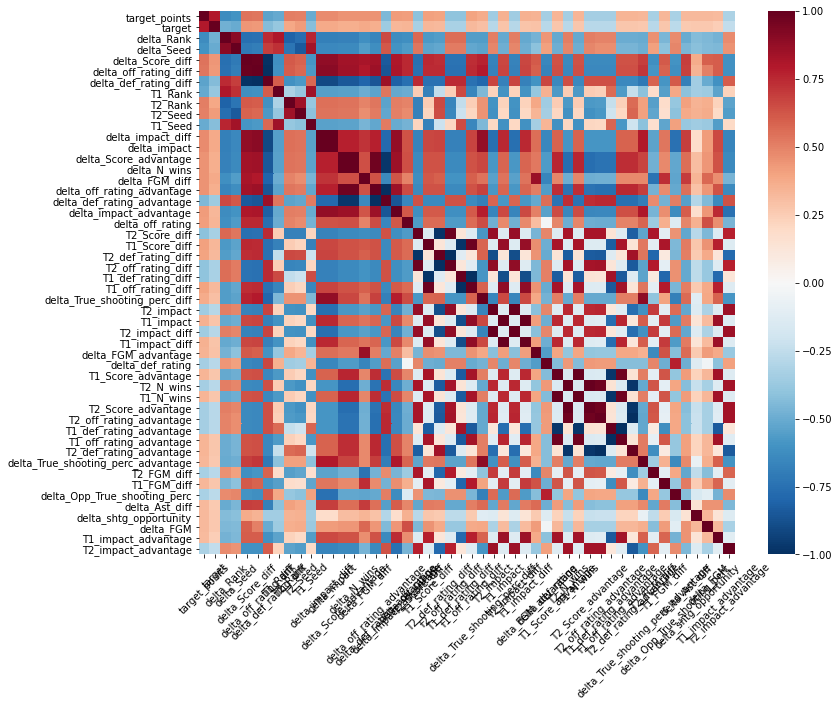

In [77]:
high_corr = tml.plot_correlations(df, target='target_points', limit=50)

                            delta_Rank  delta_Seed  delta_Score_diff  \
delta_Rank                    1.000000    0.904246         -0.757067   
delta_Seed                    0.904246    1.000000         -0.706681   
delta_Score_diff             -0.757067   -0.706681          1.000000   
delta_off_rating_diff        -0.744230   -0.688326          0.985651   
delta_def_rating_diff         0.744230    0.688326         -0.985651   
T1_Rank                       0.810338    0.732745         -0.613480   
T2_Rank                      -0.810338   -0.732745          0.613480   
T2_Seed                      -0.758582   -0.838911          0.592843   
T1_Seed                       0.758582    0.838911         -0.592843   
delta_impact_diff            -0.681862   -0.646798          0.887435   
delta_impact                 -0.681862   -0.646798          0.887435   
delta_Score_advantage        -0.672154   -0.639380          0.842458   
delta_N_wins                 -0.672154   -0.639380          0.84

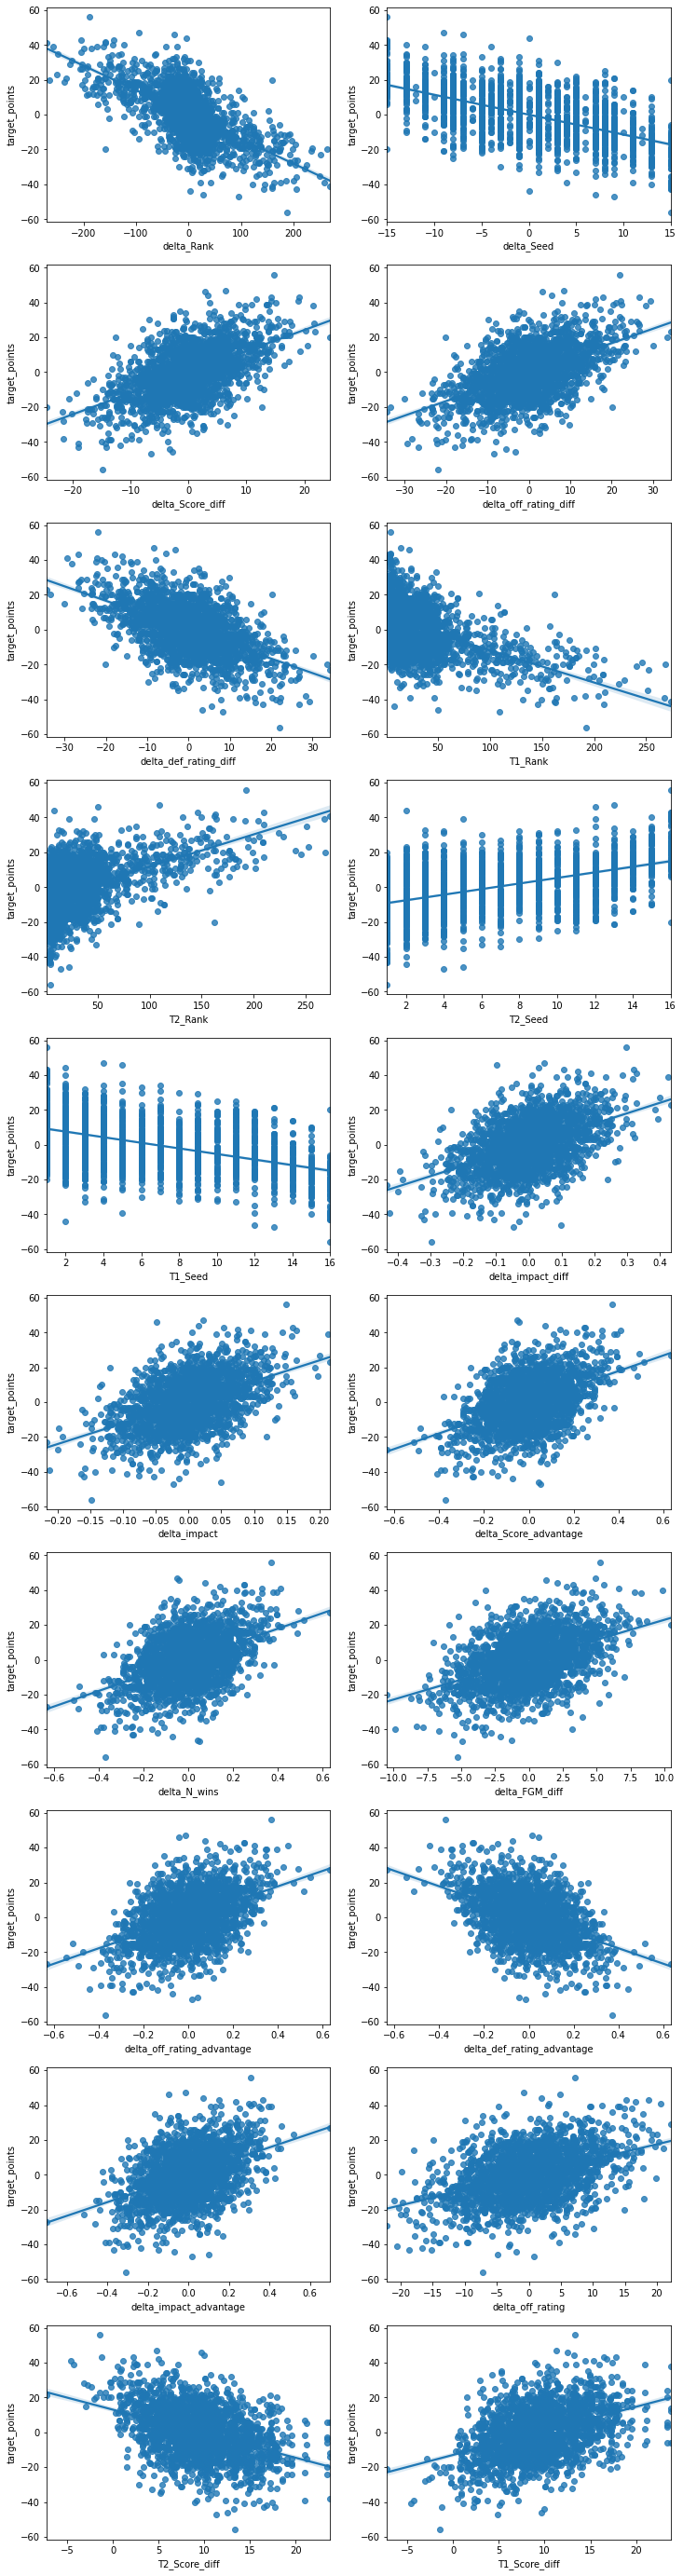

In [78]:
tml.corr_target(df, 'target_points', list(high_corr[2:22].index), x_estimator=None)

In [72]:
for col in [col for col in df if 'delta' in col]:
    df[f'sign_{col}'] = np.where(df[col]>0, 1, 0)

In [73]:
feats = []
scores = []

for col in [col for col in df if 'sign_' in col]:
    try:
        scores.append(df.groupby(col)['target'].mean()[1])
        feats.append(col)
    except KeyError:
        continue

segments = pd.DataFrame({'feat': feats, 'score': scores})
                      
segments.sort_values(by='score', ascending=False)

,feat,score
53,sign_delta_Score_diff,0.669468
76,sign_delta_off_rating_diff,0.669468
71,sign_delta_impact,0.661998
73,sign_delta_impact_diff,0.661998
30,sign_delta_FGM_diff,0.656075
...,...,...
69,sign_delta_def_rating_advantage,0.353670
89,sign_delta_upset,0.353579
70,sign_delta_def_rating_diff,0.330532
98,sign_delta_Seed,0.286389
